In [1]:
from xgboost import XGBClassifier, plot_importance
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay, 
    roc_curve, 
    auc
)
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
import optuna
import cupy as cp
from sklearn.metrics import precision_recall_curve
from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier

c:\Users\dudac\projetos\data-analysis\Projeto-Churn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\dudac\projetos\data-analysis\Projeto-Churn\.venv\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


## Funções

In [2]:
def plot_ks_curve(y_true, y_score):
    """
    y_true: valores reais (0 ou 1)
    y_score: probabilidade prevista para a classe positiva
    """

    # Probabilidades de cada classe
    score_0 = np.sort(y_score[y_true == 0])
    score_1 = np.sort(y_score[y_true == 1])

    # Limiar comum
    thresholds = np.sort(np.unique(y_score))

    # ECDF de cada classe
    ecdf_0 = np.searchsorted(score_0, thresholds, side='right') / len(score_0)
    ecdf_1 = np.searchsorted(score_1, thresholds, side='right') / len(score_1)

    # Estatística KS
    diff = np.abs(ecdf_1 - ecdf_0)
    ks = diff.max()
    idx = diff.argmax()
    ks_threshold = thresholds[idx]

    # Plot
    plt.figure(figsize=(8,6))

    plt.plot(
        thresholds,
        ecdf_0,
        label='Classe 0',
        linewidth=2
    )

    plt.plot(
        thresholds,
        ecdf_1,
        label='Classe 1',
        linewidth=2
    )

    # Linha vertical do KS
    plt.vlines(
        ks_threshold,
        ecdf_0[idx],
        ecdf_1[idx],
        colors='black',
        linestyles='dashed',
        linewidth=2,
        label=f'KS = {ks:.3f} em {ks_threshold:.3f}'
    )

    plt.xlabel('Threshold')
    plt.ylabel('Percentual abaixo do threshold')
    plt.title('KS Statistic Plot')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    return ks

In [3]:
def evaluate_model(model, X, y, plot=True):

    # Predições
    y_pred = model.predict(X)
    y_score = model.predict_proba(X)[:, 1]

    # Métricas
    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_score)
    }

    # Curva ROC
    fpr, tpr, _ = roc_curve(y, y_score)

    if plot:
        plt.figure(figsize=(7, 6))

        plt.plot(
            fpr,
            tpr,
            lw=2,
            label=f"AUC = {metrics['ROC-AUC']:.3f}"
        )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="gray",
            label="Random Classifier"
        )

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)

        plt.show()

    return pd.DataFrame([metrics]).round(2)

In [4]:
def ks_score(y_true, y_score):

    score_pos = y_score[y_true == 1]
    score_neg = y_score[y_true == 0]

    ks, _ = ks_2samp(score_pos, score_neg)

    return ks

## Dados

In [5]:
treino = "./data/train.csv"
teste = "./data/test.csv"
validacao = "./data/validation.csv"

df_treino = pd.read_csv(treino)
df_teste = pd.read_csv(teste)
df_validacao = pd.read_csv(validacao)

X_train = df_treino.drop(columns=['Churn'])
y_train = df_treino['Churn']

X_val = df_validacao.drop(columns=['Churn'])
y_val = df_validacao['Churn']

X_test = df_teste.drop(columns=['Churn'])
y_test = df_teste['Churn']


## Modelo

In [ ]:
""""
first_model_xgboost = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    max_leaves=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    scale_pos_weight=1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
)


primeiro teste realizado com XGBOOST com todas as features
"""


# Removendo Features com Baixa Importância

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

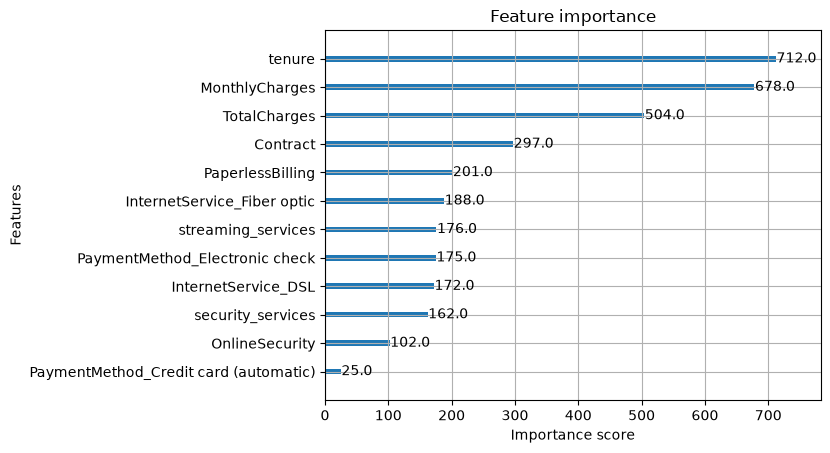

In [54]:
plot_importance(model)

In [6]:
remove = [
    'DeviceProtection',
    'Partner',
    'family_size',
    'StreamingTV',
    'gender',
    'multipleLines',
    'OnlineBackup',
    'num_services',
    'StreamingMovies',
    'bundle',
    'SeniorCitizen',
    'TechSupport',
    'PhoneService',
    'Dependents',
    'MultipleLines',
    'PaymentMethod_Mailed check',
]

X_train = X_train.drop(columns=remove)
X_val = X_val.drop(columns=remove)
X_test = X_test.drop(columns=remove)


# Optuna

In [47]:
X_train_cv = pd.concat([X_train, X_val])
y_train_cv = pd.concat([y_train, y_val])

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10, log=True),
        "reg_lambda": trial.suggest_float( "reg_lambda", 1e-5, 10, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 5),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "device": "cuda",
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []

    for tr, va in skf.split(X_train_cv, y_train_cv):

        model = XGBClassifier(**params)

        model.fit(
            X_train_cv.iloc[tr],
            y_train_cv.iloc[tr]
        )

        pred = model.predict_proba(
            X_train_cv.iloc[va]
        )[:, 1]

        #pred = (pred >= 0.5).astype(int)
        
        scores.append(
            ks_score(
                y_train_cv.iloc[va],
                pred
            )
        )

    return np.mean(scores)

study = optuna.create_study(study_name="xgb_gpu", direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=1)

best_params = study.best_params

[I 2026-07-03 02:32:01,866] A new study created in memory with name: xgb_gpu
Best trial: 0. Best value: 0.543489:   1%|          | 1/100 [00:03<05:51,  3.55s/it]

[I 2026-07-03 02:32:05,419] Trial 0 finished with value: 0.5434888601303101 and parameters: {'n_estimators': 340, 'learning_rate': 0.06247790669225906, 'max_depth': 4, 'subsample': 0.6089378139750187, 'colsample_bytree': 0.8442384829657236, 'min_child_weight': 5, 'gamma': 3.994749420198817, 'reg_alpha': 0.0001480772149757806, 'reg_lambda': 2.868687088925937, 'scale_pos_weight': 4.339405690927313}. Best is trial 0 with value: 0.5434888601303101.


Best trial: 1. Best value: 0.553409:   2%|▏         | 2/100 [00:06<04:57,  3.04s/it]

[I 2026-07-03 02:32:08,100] Trial 1 finished with value: 0.5534093379974365 and parameters: {'n_estimators': 317, 'learning_rate': 0.03861769181972853, 'max_depth': 6, 'subsample': 0.8600391392143786, 'colsample_bytree': 0.9990330440956171, 'min_child_weight': 3, 'gamma': 1.330058278004031, 'reg_alpha': 4.243755581483076, 'reg_lambda': 0.09900344479839912, 'scale_pos_weight': 0.9997668253533587}. Best is trial 1 with value: 0.5534093379974365.


Best trial: 2. Best value: 0.554833:   3%|▎         | 3/100 [00:08<04:26,  2.75s/it]

[I 2026-07-03 02:32:10,510] Trial 2 finished with value: 0.5548329949378967 and parameters: {'n_estimators': 163, 'learning_rate': 0.01239102389912888, 'max_depth': 7, 'subsample': 0.6140586725138062, 'colsample_bytree': 0.5711492680282181, 'min_child_weight': 4, 'gamma': 4.329942267238943, 'reg_alpha': 0.007958788041542665, 'reg_lambda': 0.00015576613124879615, 'scale_pos_weight': 1.2357002943215163}. Best is trial 2 with value: 0.5548329949378967.


Best trial: 2. Best value: 0.554833:   4%|▍         | 4/100 [00:12<04:52,  3.04s/it]

[I 2026-07-03 02:32:14,002] Trial 3 finished with value: 0.5419764518737793 and parameters: {'n_estimators': 448, 'learning_rate': 0.05013706859775984, 'max_depth': 4, 'subsample': 0.8411560451462978, 'colsample_bytree': 0.5246645443318011, 'min_child_weight': 19, 'gamma': 0.10022373987467248, 'reg_alpha': 0.00829301358392221, 'reg_lambda': 0.00010704184798588498, 'scale_pos_weight': 3.6462284314106315}. Best is trial 2 with value: 0.5548329949378967.


Best trial: 2. Best value: 0.554833:   5%|▌         | 5/100 [00:13<04:04,  2.57s/it]

[I 2026-07-03 02:32:15,734] Trial 4 finished with value: 0.5533056259155273 and parameters: {'n_estimators': 147, 'learning_rate': 0.040468043471985196, 'max_depth': 6, 'subsample': 0.8834036620881682, 'colsample_bytree': 0.6269842760406561, 'min_child_weight': 4, 'gamma': 1.4940668242306128, 'reg_alpha': 0.027313851623878678, 'reg_lambda': 9.317277290622334, 'scale_pos_weight': 1.2295764741522077}. Best is trial 2 with value: 0.5548329949378967.


Best trial: 2. Best value: 0.554833:   6%|▌         | 6/100 [00:18<05:08,  3.28s/it]

[I 2026-07-03 02:32:20,399] Trial 5 finished with value: 0.542690634727478 and parameters: {'n_estimators': 404, 'learning_rate': 0.03739627194434874, 'max_depth': 7, 'subsample': 0.7550584082058865, 'colsample_bytree': 0.7622329721675898, 'min_child_weight': 10, 'gamma': 1.8470437907568982, 'reg_alpha': 0.095281086838758, 'reg_lambda': 0.0005965291221543067, 'scale_pos_weight': 2.1759133869383027}. Best is trial 2 with value: 0.5548329949378967.


Best trial: 2. Best value: 0.554833:   7%|▋         | 7/100 [00:25<07:10,  4.63s/it]

[I 2026-07-03 02:32:27,802] Trial 6 finished with value: 0.5511363744735718 and parameters: {'n_estimators': 452, 'learning_rate': 0.005137739066372189, 'max_depth': 7, 'subsample': 0.734021538020604, 'colsample_bytree': 0.6359036028478097, 'min_child_weight': 12, 'gamma': 3.3730221150710116, 'reg_alpha': 0.000694639709883222, 'reg_lambda': 2.4411833197674024, 'scale_pos_weight': 4.54398570519961}. Best is trial 2 with value: 0.5548329949378967.


Best trial: 7. Best value: 0.556626:   8%|▊         | 8/100 [00:28<06:05,  3.97s/it]

[I 2026-07-03 02:32:30,356] Trial 7 finished with value: 0.5566257238388062 and parameters: {'n_estimators': 307, 'learning_rate': 0.02453566148670581, 'max_depth': 4, 'subsample': 0.8599191353419144, 'colsample_bytree': 0.5654946090299547, 'min_child_weight': 15, 'gamma': 4.438424291140766, 'reg_alpha': 5.019828783121444, 'reg_lambda': 0.4955887611682364, 'scale_pos_weight': 3.7158041462961577}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 7. Best value: 0.556626:   9%|▉         | 9/100 [00:35<07:22,  4.86s/it]

[I 2026-07-03 02:32:37,177] Trial 8 finished with value: 0.5293191075325012 and parameters: {'n_estimators': 459, 'learning_rate': 0.05308439836479619, 'max_depth': 8, 'subsample': 0.6708868646179743, 'colsample_bytree': 0.5163901945489644, 'min_child_weight': 8, 'gamma': 1.6682321289426394, 'reg_alpha': 0.13610591897680605, 'reg_lambda': 0.0003654032585433477, 'scale_pos_weight': 3.8806086473609267}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 7. Best value: 0.556626:  10%|█         | 10/100 [00:37<06:02,  4.03s/it]

[I 2026-07-03 02:32:39,352] Trial 9 finished with value: 0.554019033908844 and parameters: {'n_estimators': 252, 'learning_rate': 0.04279591467819722, 'max_depth': 7, 'subsample': 0.6493461883666504, 'colsample_bytree': 0.8830519479726311, 'min_child_weight': 19, 'gamma': 4.8172846856888345, 'reg_alpha': 0.0009585463898101136, 'reg_lambda': 7.296198366404088, 'scale_pos_weight': 1.8086159791541097}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 7. Best value: 0.556626:  11%|█         | 11/100 [00:38<04:39,  3.14s/it]

[I 2026-07-03 02:32:40,481] Trial 10 finished with value: 0.5491729974746704 and parameters: {'n_estimators': 213, 'learning_rate': 0.17658248742457008, 'max_depth': 3, 'subsample': 0.9908126432966936, 'colsample_bytree': 0.7067322640083471, 'min_child_weight': 13, 'gamma': 2.9668216552314433, 'reg_alpha': 1.3903401953895394e-05, 'reg_lambda': 0.026341020052959314, 'scale_pos_weight': 2.935238802423706}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 7. Best value: 0.556626:  12%|█▏        | 12/100 [00:40<03:51,  2.63s/it]

[I 2026-07-03 02:32:41,943] Trial 11 finished with value: 0.5562814474105835 and parameters: {'n_estimators': 102, 'learning_rate': 0.010799419021647333, 'max_depth': 5, 'subsample': 0.986225485331157, 'colsample_bytree': 0.5967573713014395, 'min_child_weight': 15, 'gamma': 4.786710644752624, 'reg_alpha': 4.864277990492869, 'reg_lambda': 0.010206558777954448, 'scale_pos_weight': 2.627100462883365}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 7. Best value: 0.556626:  13%|█▎        | 13/100 [00:41<03:18,  2.28s/it]

[I 2026-07-03 02:32:43,402] Trial 12 finished with value: 0.5553637742996216 and parameters: {'n_estimators': 104, 'learning_rate': 0.014470926416119294, 'max_depth': 5, 'subsample': 0.975033243121992, 'colsample_bytree': 0.63215509326303, 'min_child_weight': 15, 'gamma': 4.88873043164775, 'reg_alpha': 7.593241040344694, 'reg_lambda': 0.01714482769750647, 'scale_pos_weight': 2.923829102016891}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 7. Best value: 0.556626:  14%|█▍        | 14/100 [00:44<03:30,  2.45s/it]

[I 2026-07-03 02:32:46,237] Trial 13 finished with value: 0.5528980493545532 and parameters: {'n_estimators': 278, 'learning_rate': 0.01533481135641659, 'max_depth': 4, 'subsample': 0.9301798662853846, 'colsample_bytree': 0.7086394313016221, 'min_child_weight': 16, 'gamma': 3.8669144104245983, 'reg_alpha': 0.8287184422413528, 'reg_lambda': 0.43013341114492576, 'scale_pos_weight': 2.9470631073373545}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 7. Best value: 0.556626:  15%|█▌        | 15/100 [00:47<03:42,  2.62s/it]

[I 2026-07-03 02:32:49,270] Trial 14 finished with value: 0.5565188527107239 and parameters: {'n_estimators': 365, 'learning_rate': 0.007297575021898606, 'max_depth': 3, 'subsample': 0.7978484597570334, 'colsample_bytree': 0.5690915491961179, 'min_child_weight': 16, 'gamma': 2.8544509779858185, 'reg_alpha': 1.2066438825973995, 'reg_lambda': 1.0587007453058828e-05, 'scale_pos_weight': 3.4310345327544023}. Best is trial 7 with value: 0.5566257238388062.


Best trial: 15. Best value: 0.556861:  16%|█▌        | 16/100 [00:50<03:50,  2.75s/it]

[I 2026-07-03 02:32:52,309] Trial 15 finished with value: 0.5568606853485107 and parameters: {'n_estimators': 365, 'learning_rate': 0.006423177941469314, 'max_depth': 3, 'subsample': 0.8064897663509395, 'colsample_bytree': 0.5004804879756043, 'min_child_weight': 17, 'gamma': 2.651891976240941, 'reg_alpha': 0.37919439863506765, 'reg_lambda': 1.05799173420157e-05, 'scale_pos_weight': 3.6095160482408777}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  17%|█▋        | 17/100 [00:53<03:59,  2.89s/it]

[I 2026-07-03 02:32:55,520] Trial 16 finished with value: 0.5528976917266846 and parameters: {'n_estimators': 385, 'learning_rate': 0.01942988807473312, 'max_depth': 3, 'subsample': 0.7891467895863451, 'colsample_bytree': 0.5081802684848554, 'min_child_weight': 20, 'gamma': 2.521583070759939, 'reg_alpha': 0.48207528283131296, 'reg_lambda': 0.0014530779007900444, 'scale_pos_weight': 4.170816352077929}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  18%|█▊        | 18/100 [00:56<04:06,  3.00s/it]

[I 2026-07-03 02:32:58,783] Trial 17 finished with value: 0.5419840216636658 and parameters: {'n_estimators': 303, 'learning_rate': 0.09014680110307817, 'max_depth': 4, 'subsample': 0.9114223377653217, 'colsample_bytree': 0.7067857886607632, 'min_child_weight': 17, 'gamma': 0.38340905815242143, 'reg_alpha': 0.20143642360715153, 'reg_lambda': 1.8791284284233575e-05, 'scale_pos_weight': 4.732311570679112}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  19%|█▉        | 19/100 [01:01<04:47,  3.55s/it]

[I 2026-07-03 02:33:03,611] Trial 18 finished with value: 0.5470160245895386 and parameters: {'n_estimators': 495, 'learning_rate': 0.024401163190943043, 'max_depth': 5, 'subsample': 0.8270342935338282, 'colsample_bytree': 0.5523329362258731, 'min_child_weight': 12, 'gamma': 2.180455216861963, 'reg_alpha': 1.059672621801922, 'reg_lambda': 0.0028850150519215403, 'scale_pos_weight': 3.443840670719017}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  20%|██        | 20/100 [01:03<04:07,  3.09s/it]

[I 2026-07-03 02:33:05,631] Trial 19 finished with value: 0.5555936098098755 and parameters: {'n_estimators': 237, 'learning_rate': 0.007263214222701384, 'max_depth': 3, 'subsample': 0.7156531391472194, 'colsample_bytree': 0.6572032138699061, 'min_child_weight': 8, 'gamma': 0.8581838194258935, 'reg_alpha': 0.04437672662152048, 'reg_lambda': 0.31682534022705505, 'scale_pos_weight': 4.965668278694525}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  21%|██        | 21/100 [01:06<03:44,  2.84s/it]

[I 2026-07-03 02:33:07,895] Trial 20 finished with value: 0.5556430816650391 and parameters: {'n_estimators': 339, 'learning_rate': 0.027041988851345056, 'max_depth': 4, 'subsample': 0.806160202457086, 'colsample_bytree': 0.5061685363373671, 'min_child_weight': 18, 'gamma': 3.4268946714755746, 'reg_alpha': 2.0355565455086957, 'reg_lambda': 5.5706844402469955e-05, 'scale_pos_weight': 0.5535594947446669}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  22%|██▏       | 22/100 [01:09<03:48,  2.93s/it]

[I 2026-07-03 02:33:11,018] Trial 21 finished with value: 0.556467592716217 and parameters: {'n_estimators': 381, 'learning_rate': 0.008129671139772176, 'max_depth': 3, 'subsample': 0.7760182902495558, 'colsample_bytree': 0.5775813199719309, 'min_child_weight': 14, 'gamma': 2.7990993535312243, 'reg_alpha': 0.3845784490036, 'reg_lambda': 1.2802025178018326e-05, 'scale_pos_weight': 3.350022010374209}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  23%|██▎       | 23/100 [01:12<03:52,  3.01s/it]

[I 2026-07-03 02:33:14,234] Trial 22 finished with value: 0.5557111501693726 and parameters: {'n_estimators': 369, 'learning_rate': 0.005422786080494184, 'max_depth': 3, 'subsample': 0.8794798722247398, 'colsample_bytree': 0.5570271553841772, 'min_child_weight': 17, 'gamma': 3.3468123798889575, 'reg_alpha': 1.7952177756980257, 'reg_lambda': 3.415151991821909e-05, 'scale_pos_weight': 3.7399900500237466}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  24%|██▍       | 24/100 [01:14<03:34,  2.82s/it]

[I 2026-07-03 02:33:16,599] Trial 23 finished with value: 0.5568071603775024 and parameters: {'n_estimators': 285, 'learning_rate': 0.00803709363464513, 'max_depth': 3, 'subsample': 0.8293853529860217, 'colsample_bytree': 0.6024557990424639, 'min_child_weight': 11, 'gamma': 2.1679895657576678, 'reg_alpha': 8.142545032123964, 'reg_lambda': 1.3005431902353976e-05, 'scale_pos_weight': 4.037649393482165}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  25%|██▌       | 25/100 [01:18<03:42,  2.97s/it]

[I 2026-07-03 02:33:19,927] Trial 24 finished with value: 0.556335985660553 and parameters: {'n_estimators': 293, 'learning_rate': 0.009957985483550452, 'max_depth': 4, 'subsample': 0.9266446289355644, 'colsample_bytree': 0.6665897467851959, 'min_child_weight': 11, 'gamma': 2.197730354998065, 'reg_alpha': 9.746803709692903, 'reg_lambda': 0.004521509651554436, 'scale_pos_weight': 4.095374096968717}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  26%|██▌       | 26/100 [01:19<03:10,  2.58s/it]

[I 2026-07-03 02:33:21,592] Trial 25 finished with value: 0.5536588430404663 and parameters: {'n_estimators': 203, 'learning_rate': 0.01927546060754568, 'max_depth': 3, 'subsample': 0.836751239617648, 'colsample_bytree': 0.6103251900425246, 'min_child_weight': 9, 'gamma': 0.9574205438082068, 'reg_alpha': 2.733709153978084, 'reg_lambda': 0.00032067698138594033, 'scale_pos_weight': 4.039782899611721}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 15. Best value: 0.556861:  27%|██▋       | 27/100 [01:21<02:59,  2.46s/it]

[I 2026-07-03 02:33:23,764] Trial 26 finished with value: 0.5513696074485779 and parameters: {'n_estimators': 267, 'learning_rate': 0.08864517576095707, 'max_depth': 5, 'subsample': 0.8880577181304623, 'colsample_bytree': 0.5441071135550599, 'min_child_weight': 14, 'gamma': 2.1056704470470633, 'reg_alpha': 0.3932433196054269, 'reg_lambda': 0.05657756764113352, 'scale_pos_weight': 3.2033258062979755}. Best is trial 15 with value: 0.5568606853485107.


Best trial: 27. Best value: 0.557555:  28%|██▊       | 28/100 [01:25<03:22,  2.82s/it]

[I 2026-07-03 02:33:27,419] Trial 27 finished with value: 0.5575551390647888 and parameters: {'n_estimators': 416, 'learning_rate': 0.006321873409972956, 'max_depth': 4, 'subsample': 0.6991468143191402, 'colsample_bytree': 0.7677171826131333, 'min_child_weight': 1, 'gamma': 4.366453369175018, 'reg_alpha': 9.675937211759171, 'reg_lambda': 5.653044714282258e-05, 'scale_pos_weight': 2.536844239896384}. Best is trial 27 with value: 0.5575551390647888.


Best trial: 27. Best value: 0.557555:  29%|██▉       | 29/100 [01:28<03:26,  2.91s/it]

[I 2026-07-03 02:33:30,550] Trial 28 finished with value: 0.5553561449050903 and parameters: {'n_estimators': 427, 'learning_rate': 0.006402868862883658, 'max_depth': 3, 'subsample': 0.6804782778439463, 'colsample_bytree': 0.818563229831609, 'min_child_weight': 1, 'gamma': 2.486383000319505, 'reg_alpha': 0.043446083740037646, 'reg_lambda': 5.6374597303868644e-05, 'scale_pos_weight': 2.405445706010524}. Best is trial 27 with value: 0.5575551390647888.


Best trial: 27. Best value: 0.557555:  30%|███       | 30/100 [01:32<03:36,  3.10s/it]

[I 2026-07-03 02:33:34,090] Trial 29 finished with value: 0.5530528426170349 and parameters: {'n_estimators': 341, 'learning_rate': 0.009022315488691535, 'max_depth': 4, 'subsample': 0.729676520401324, 'colsample_bytree': 0.8789077360528096, 'min_child_weight': 7, 'gamma': 3.958821023725671, 'reg_alpha': 9.618342344034954, 'reg_lambda': 3.089466097753155e-05, 'scale_pos_weight': 1.9112416095856248}. Best is trial 27 with value: 0.5575551390647888.


Best trial: 27. Best value: 0.557555:  31%|███       | 31/100 [01:36<03:54,  3.40s/it]

[I 2026-07-03 02:33:38,201] Trial 30 finished with value: 0.5529367923736572 and parameters: {'n_estimators': 406, 'learning_rate': 0.006152994780512953, 'max_depth': 4, 'subsample': 0.7050066896432379, 'colsample_bytree': 0.9542453167243967, 'min_child_weight': 6, 'gamma': 1.0413733199685995, 'reg_alpha': 0.7728004752828344, 'reg_lambda': 0.0001480341243991414, 'scale_pos_weight': 4.332815752945835}. Best is trial 27 with value: 0.5575551390647888.


Best trial: 27. Best value: 0.557555:  32%|███▏      | 32/100 [01:39<03:50,  3.40s/it]

[I 2026-07-03 02:33:41,583] Trial 31 finished with value: 0.5562101602554321 and parameters: {'n_estimators': 338, 'learning_rate': 0.005027869138945428, 'max_depth': 4, 'subsample': 0.7586808133740724, 'colsample_bytree': 0.7702861444809305, 'min_child_weight': 2, 'gamma': 4.250241026208499, 'reg_alpha': 3.2125855541040242, 'reg_lambda': 1.1139330674269067e-05, 'scale_pos_weight': 4.507101408153304}. Best is trial 27 with value: 0.5575551390647888.


Best trial: 27. Best value: 0.557555:  33%|███▎      | 33/100 [01:42<03:33,  3.18s/it]

[I 2026-07-03 02:33:44,270] Trial 32 finished with value: 0.5538094639778137 and parameters: {'n_estimators': 330, 'learning_rate': 0.011662081376961009, 'max_depth': 3, 'subsample': 0.854282918454139, 'colsample_bytree': 0.7581315890113031, 'min_child_weight': 18, 'gamma': 4.44821839049581, 'reg_alpha': 4.352930520687263, 'reg_lambda': 0.7208707430204008, 'scale_pos_weight': 3.686322748261124}. Best is trial 27 with value: 0.5575551390647888.


Best trial: 27. Best value: 0.557555:  34%|███▍      | 34/100 [01:46<03:43,  3.38s/it]

[I 2026-07-03 02:33:48,122] Trial 33 finished with value: 0.5486588478088379 and parameters: {'n_estimators': 309, 'learning_rate': 0.008784243617149974, 'max_depth': 5, 'subsample': 0.8172119684805872, 'colsample_bytree': 0.9312351253178194, 'min_child_weight': 6, 'gamma': 3.6763344468995416, 'reg_alpha': 2.493495732664766, 'reg_lambda': 8.70367483741289e-05, 'scale_pos_weight': 3.129942752789484}. Best is trial 27 with value: 0.5575551390647888.


Best trial: 34. Best value: 0.557844:  35%|███▌      | 35/100 [01:48<03:23,  3.13s/it]

[I 2026-07-03 02:33:50,675] Trial 34 finished with value: 0.5578435063362122 and parameters: {'n_estimators': 358, 'learning_rate': 0.028463665557428717, 'max_depth': 4, 'subsample': 0.6393893977819205, 'colsample_bytree': 0.5951761713796462, 'min_child_weight': 20, 'gamma': 4.522505983841034, 'reg_alpha': 5.049518114117758, 'reg_lambda': 2.8325172542426565e-05, 'scale_pos_weight': 2.502353140091797}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  36%|███▌      | 36/100 [01:52<03:35,  3.37s/it]

[I 2026-07-03 02:33:54,585] Trial 35 finished with value: 0.556111216545105 and parameters: {'n_estimators': 421, 'learning_rate': 0.01436909986719607, 'max_depth': 4, 'subsample': 0.6108126529459899, 'colsample_bytree': 0.6695556547234551, 'min_child_weight': 19, 'gamma': 4.170433042824229, 'reg_alpha': 0.3299714659722818, 'reg_lambda': 2.883965152528373e-05, 'scale_pos_weight': 2.622123606929952}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  37%|███▋      | 37/100 [01:55<03:19,  3.17s/it]

[I 2026-07-03 02:33:57,307] Trial 36 finished with value: 0.5565733909606934 and parameters: {'n_estimators': 495, 'learning_rate': 0.07522520226174739, 'max_depth': 6, 'subsample': 0.6543234532869896, 'colsample_bytree': 0.7870267163691802, 'min_child_weight': 20, 'gamma': 4.575716777473367, 'reg_alpha': 0.011714047776505221, 'reg_lambda': 0.00025073045627239303, 'scale_pos_weight': 1.6851345512911218}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  38%|███▊      | 38/100 [01:57<03:02,  2.94s/it]

[I 2026-07-03 02:33:59,701] Trial 37 finished with value: 0.5393834710121155 and parameters: {'n_estimators': 359, 'learning_rate': 0.14284133217552158, 'max_depth': 3, 'subsample': 0.6043270237780815, 'colsample_bytree': 0.5963788624644075, 'min_child_weight': 4, 'gamma': 3.1270552224003385, 'reg_alpha': 0.0906666134122683, 'reg_lambda': 0.0006644564397427821, 'scale_pos_weight': 2.2464480414413592}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  39%|███▉      | 39/100 [02:01<03:21,  3.30s/it]

[I 2026-07-03 02:34:03,853] Trial 38 finished with value: 0.5542410612106323 and parameters: {'n_estimators': 406, 'learning_rate': 0.006620436322308828, 'max_depth': 4, 'subsample': 0.6333613773671887, 'colsample_bytree': 0.7365159339689382, 'min_child_weight': 10, 'gamma': 2.5442621146650612, 'reg_alpha': 1.6145121598159942, 'reg_lambda': 7.034843495028386e-05, 'scale_pos_weight': 2.6289520758217635}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  40%|████      | 40/100 [02:04<03:09,  3.16s/it]

[I 2026-07-03 02:34:06,688] Trial 39 finished with value: 0.5536657571792603 and parameters: {'n_estimators': 437, 'learning_rate': 0.029197233691600828, 'max_depth': 5, 'subsample': 0.702266638855835, 'colsample_bytree': 0.5298153058596449, 'min_child_weight': 20, 'gamma': 3.6015427949453405, 'reg_alpha': 5.406298039467867, 'reg_lambda': 2.4568551003552588e-05, 'scale_pos_weight': 1.1283441189729257}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  41%|████      | 41/100 [02:10<03:46,  3.85s/it]

[I 2026-07-03 02:34:12,132] Trial 40 finished with value: 0.5498337745666504 and parameters: {'n_estimators': 389, 'learning_rate': 0.018846220070407153, 'max_depth': 6, 'subsample': 0.6302831885404651, 'colsample_bytree': 0.8177943107499, 'min_child_weight': 18, 'gamma': 1.4040568890163048, 'reg_alpha': 0.0012254174970687157, 'reg_lambda': 0.0001505744255872766, 'scale_pos_weight': 1.5460699515369332}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  42%|████▏     | 42/100 [02:12<03:18,  3.43s/it]

[I 2026-07-03 02:34:14,588] Trial 41 finished with value: 0.5558075904846191 and parameters: {'n_estimators': 325, 'learning_rate': 0.031442451654393584, 'max_depth': 4, 'subsample': 0.8549421820125893, 'colsample_bytree': 0.5830136159525434, 'min_child_weight': 16, 'gamma': 4.58383705040811, 'reg_alpha': 4.67583422905461, 'reg_lambda': 1.6159226542350895, 'scale_pos_weight': 3.8591023111753184}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  43%|████▎     | 43/100 [02:15<02:59,  3.15s/it]

[I 2026-07-03 02:34:17,080] Trial 42 finished with value: 0.5557042956352234 and parameters: {'n_estimators': 289, 'learning_rate': 0.022573124722814433, 'max_depth': 4, 'subsample': 0.7586369989054125, 'colsample_bytree': 0.5354759045894326, 'min_child_weight': 13, 'gamma': 4.099735795492571, 'reg_alpha': 7.237173848611732, 'reg_lambda': 4.534206315294276e-05, 'scale_pos_weight': 2.0874877613443115}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  44%|████▍     | 44/100 [02:20<03:23,  3.64s/it]

[I 2026-07-03 02:34:21,866] Trial 43 finished with value: 0.536346971988678 and parameters: {'n_estimators': 306, 'learning_rate': 0.03600638499981819, 'max_depth': 8, 'subsample': 0.6790852743472214, 'colsample_bytree': 0.6168416914166298, 'min_child_weight': 3, 'gamma': 1.738138451943454, 'reg_alpha': 0.7269806652319182, 'reg_lambda': 0.15187601020262131, 'scale_pos_weight': 2.785608007858218}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  45%|████▌     | 45/100 [02:22<03:06,  3.39s/it]

[I 2026-07-03 02:34:24,675] Trial 44 finished with value: 0.5521124601364136 and parameters: {'n_estimators': 352, 'learning_rate': 0.013325991325231882, 'max_depth': 3, 'subsample': 0.8769296844821841, 'colsample_bytree': 0.6449725156554436, 'min_child_weight': 17, 'gamma': 4.92119609065965, 'reg_alpha': 0.18503570328003502, 'reg_lambda': 1.5890821069264284e-05, 'scale_pos_weight': 3.5293656115073437}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  46%|████▌     | 46/100 [02:24<02:36,  2.90s/it]

[I 2026-07-03 02:34:26,421] Trial 45 finished with value: 0.5560336112976074 and parameters: {'n_estimators': 251, 'learning_rate': 0.0509626247014679, 'max_depth': 4, 'subsample': 0.9033253123891286, 'colsample_bytree': 0.5264374245995757, 'min_child_weight': 15, 'gamma': 4.592346155070557, 'reg_alpha': 4.968737168584645e-05, 'reg_lambda': 2.1495940553778206e-05, 'scale_pos_weight': 3.1871104132795347}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  47%|████▋     | 47/100 [02:28<02:52,  3.25s/it]

[I 2026-07-03 02:34:30,490] Trial 46 finished with value: 0.5532734394073486 and parameters: {'n_estimators': 453, 'learning_rate': 0.01075680695856179, 'max_depth': 5, 'subsample': 0.9468503088417424, 'colsample_bytree': 0.6805118811244852, 'min_child_weight': 19, 'gamma': 3.7552330206887934, 'reg_alpha': 3.2131119637393804, 'reg_lambda': 0.0005935507489566648, 'scale_pos_weight': 1.4042296492809037}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  48%|████▊     | 48/100 [02:30<02:22,  2.74s/it]

[I 2026-07-03 02:34:32,056] Trial 47 finished with value: 0.5499306917190552 and parameters: {'n_estimators': 223, 'learning_rate': 0.0611912091507694, 'max_depth': 3, 'subsample': 0.7721359738961102, 'colsample_bytree': 0.5018798211769933, 'min_child_weight': 11, 'gamma': 1.951590858755131, 'reg_alpha': 1.3463219778771385, 'reg_lambda': 8.281153626503481e-05, 'scale_pos_weight': 3.8781383875782964}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  49%|████▉     | 49/100 [02:32<02:18,  2.71s/it]

[I 2026-07-03 02:34:34,680] Trial 48 finished with value: 0.5493406057357788 and parameters: {'n_estimators': 468, 'learning_rate': 0.04450430091231833, 'max_depth': 4, 'subsample': 0.8206938419211957, 'colsample_bytree': 0.6019075277160553, 'min_child_weight': 14, 'gamma': 4.9894517854849365, 'reg_alpha': 0.001963933778085037, 'reg_lambda': 1.0077454888128052e-05, 'scale_pos_weight': 2.4002035953663463}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  50%|█████     | 50/100 [02:34<02:00,  2.41s/it]

[I 2026-07-03 02:34:36,382] Trial 49 finished with value: 0.5537666082382202 and parameters: {'n_estimators': 187, 'learning_rate': 0.007659167813830539, 'max_depth': 3, 'subsample': 0.6579752433746994, 'colsample_bytree': 0.5648919829891934, 'min_child_weight': 18, 'gamma': 4.385566437242057, 'reg_alpha': 9.827740179863827, 'reg_lambda': 0.007827175535035575, 'scale_pos_weight': 4.204686668767888}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  51%|█████     | 51/100 [02:38<02:18,  2.83s/it]

[I 2026-07-03 02:34:40,190] Trial 50 finished with value: 0.5516220331192017 and parameters: {'n_estimators': 272, 'learning_rate': 0.01671759139549542, 'max_depth': 5, 'subsample': 0.7420015157369856, 'colsample_bytree': 0.6270546798083083, 'min_child_weight': 16, 'gamma': 3.1217595594312497, 'reg_alpha': 0.6577085754868367, 'reg_lambda': 0.0013826346442558167, 'scale_pos_weight': 4.5296038644052805}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  52%|█████▏    | 52/100 [02:40<02:11,  2.74s/it]

[I 2026-07-03 02:34:42,718] Trial 51 finished with value: 0.5517615079879761 and parameters: {'n_estimators': 496, 'learning_rate': 0.09987940795253278, 'max_depth': 6, 'subsample': 0.6354518942099785, 'colsample_bytree': 0.7999944371683922, 'min_child_weight': 20, 'gamma': 4.633716240238566, 'reg_alpha': 0.007823656050034423, 'reg_lambda': 0.0002734879349326858, 'scale_pos_weight': 0.8996583241592215}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  53%|█████▎    | 53/100 [02:43<02:08,  2.73s/it]

[I 2026-07-03 02:34:45,435] Trial 52 finished with value: 0.5544084310531616 and parameters: {'n_estimators': 480, 'learning_rate': 0.08007687651777283, 'max_depth': 6, 'subsample': 0.6978278278975847, 'colsample_bytree': 0.8473853131928976, 'min_child_weight': 20, 'gamma': 4.712077140191335, 'reg_alpha': 0.01500970692714503, 'reg_lambda': 4.86405435471038, 'scale_pos_weight': 1.686465256385501}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  54%|█████▍    | 54/100 [02:45<01:57,  2.54s/it]

[I 2026-07-03 02:34:47,542] Trial 53 finished with value: 0.5524477362632751 and parameters: {'n_estimators': 379, 'learning_rate': 0.12457308897738009, 'max_depth': 8, 'subsample': 0.6633238433810162, 'colsample_bytree': 0.7305135224809354, 'min_child_weight': 19, 'gamma': 4.411996348839887, 'reg_alpha': 3.63004143255369, 'reg_lambda': 0.00018538086403054494, 'scale_pos_weight': 1.9337231238320638}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  55%|█████▌    | 55/100 [02:48<01:58,  2.64s/it]

[I 2026-07-03 02:34:50,399] Trial 54 finished with value: 0.5343528389930725 and parameters: {'n_estimators': 317, 'learning_rate': 0.19104155786483693, 'max_depth': 7, 'subsample': 0.644409800978176, 'colsample_bytree': 0.7959596254782918, 'min_child_weight': 17, 'gamma': 4.051151926643286, 'reg_alpha': 0.00017957489788775086, 'reg_lambda': 4.3561636112773884e-05, 'scale_pos_weight': 3.6076289106257575}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  56%|█████▌    | 56/100 [02:51<02:03,  2.80s/it]

[I 2026-07-03 02:34:53,592] Trial 55 finished with value: 0.5493314266204834 and parameters: {'n_estimators': 392, 'learning_rate': 0.03526496621114724, 'max_depth': 6, 'subsample': 0.866316828088162, 'colsample_bytree': 0.6900996977290311, 'min_child_weight': 19, 'gamma': 3.8180918463098337, 'reg_alpha': 0.004699168720420194, 'reg_lambda': 2.001834897511356e-05, 'scale_pos_weight': 3.0046508189220154}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  57%|█████▋    | 57/100 [02:59<03:06,  4.33s/it]

[I 2026-07-03 02:35:01,479] Trial 56 finished with value: 0.5547934174537659 and parameters: {'n_estimators': 478, 'learning_rate': 0.00564980051908704, 'max_depth': 7, 'subsample': 0.6194439348152133, 'colsample_bytree': 0.5808610363749245, 'min_child_weight': 12, 'gamma': 0.12354322958730446, 'reg_alpha': 0.10033032188443904, 'reg_lambda': 0.00011562818880855703, 'scale_pos_weight': 0.722737762164321}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  58%|█████▊    | 58/100 [03:02<02:42,  3.88s/it]

[I 2026-07-03 02:35:04,311] Trial 57 finished with value: 0.5482999682426453 and parameters: {'n_estimators': 434, 'learning_rate': 0.06816539722945118, 'max_depth': 3, 'subsample': 0.8384815794245047, 'colsample_bytree': 0.5534827929759758, 'min_child_weight': 16, 'gamma': 1.5793286122292154, 'reg_alpha': 5.155066373602084, 'reg_lambda': 3.980508735721226e-05, 'scale_pos_weight': 3.361970318212755}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  59%|█████▉    | 59/100 [03:05<02:28,  3.62s/it]

[I 2026-07-03 02:35:07,319] Trial 58 finished with value: 0.5549260377883911 and parameters: {'n_estimators': 358, 'learning_rate': 0.008734035675169536, 'max_depth': 3, 'subsample': 0.6848792012673866, 'colsample_bytree': 0.5234646115884893, 'min_child_weight': 13, 'gamma': 2.363728539441898, 'reg_alpha': 1.8540099790293816, 'reg_lambda': 0.07192637040981416, 'scale_pos_weight': 1.2812077769734396}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  60%|██████    | 60/100 [03:09<02:27,  3.69s/it]

[I 2026-07-03 02:35:11,172] Trial 59 finished with value: 0.5507055521011353 and parameters: {'n_estimators': 285, 'learning_rate': 0.009979528292556303, 'max_depth': 5, 'subsample': 0.8045163645890013, 'colsample_bytree': 0.7344818935534325, 'min_child_weight': 5, 'gamma': 4.755248863449771, 'reg_alpha': 0.0003739314590606112, 'reg_lambda': 0.028933521741165903, 'scale_pos_weight': 4.032861372509254}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  61%|██████    | 61/100 [03:13<02:24,  3.70s/it]

[I 2026-07-03 02:35:14,906] Trial 60 finished with value: 0.5551660656929016 and parameters: {'n_estimators': 348, 'learning_rate': 0.00682908969619017, 'max_depth': 4, 'subsample': 0.7840203285243627, 'colsample_bytree': 0.861297724473086, 'min_child_weight': 15, 'gamma': 3.485572940992951, 'reg_alpha': 6.514477057358949, 'reg_lambda': 0.00023411484817211075, 'scale_pos_weight': 2.759500297879876}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  62%|██████▏   | 62/100 [03:16<02:12,  3.50s/it]

[I 2026-07-03 02:35:17,928] Trial 61 finished with value: 0.5563139915466309 and parameters: {'n_estimators': 368, 'learning_rate': 0.007877387603874195, 'max_depth': 3, 'subsample': 0.8022266540207783, 'colsample_bytree': 0.567576158834374, 'min_child_weight': 17, 'gamma': 2.6942664235446703, 'reg_alpha': 1.1221305917237185, 'reg_lambda': 1.0502814876812661e-05, 'scale_pos_weight': 3.789866931199657}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  63%|██████▎   | 63/100 [03:19<02:09,  3.51s/it]

[I 2026-07-03 02:35:21,475] Trial 62 finished with value: 0.5551128387451172 and parameters: {'n_estimators': 414, 'learning_rate': 0.01234033473705732, 'max_depth': 3, 'subsample': 0.727387014368676, 'colsample_bytree': 0.6432069201222868, 'min_child_weight': 15, 'gamma': 1.946094498253514, 'reg_alpha': 2.734207251837143, 'reg_lambda': 2.1334527887330978e-05, 'scale_pos_weight': 3.4534373701138144}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  64%|██████▍   | 64/100 [03:22<01:58,  3.29s/it]

[I 2026-07-03 02:35:24,250] Trial 63 finished with value: 0.5562907457351685 and parameters: {'n_estimators': 325, 'learning_rate': 0.00584950729352724, 'max_depth': 3, 'subsample': 0.7916765156026427, 'colsample_bytree': 0.5423513258903869, 'min_child_weight': 18, 'gamma': 2.7337045012728707, 'reg_alpha': 1.1780699391476395, 'reg_lambda': 1.6670359407153152e-05, 'scale_pos_weight': 4.3480453922634785}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  65%|██████▌   | 65/100 [03:26<02:05,  3.60s/it]

[I 2026-07-03 02:35:28,567] Trial 64 finished with value: 0.5530365705490112 and parameters: {'n_estimators': 399, 'learning_rate': 0.0071283739718691385, 'max_depth': 4, 'subsample': 0.8464895040531955, 'colsample_bytree': 0.9985251267104018, 'min_child_weight': 9, 'gamma': 2.9167196990599673, 'reg_alpha': 0.5116255353663584, 'reg_lambda': 3.5104482676756746e-05, 'scale_pos_weight': 3.2977844567051635}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 34. Best value: 0.557844:  66%|██████▌   | 66/100 [03:29<01:54,  3.37s/it]

[I 2026-07-03 02:35:31,411] Trial 65 finished with value: 0.5535491108894348 and parameters: {'n_estimators': 371, 'learning_rate': 0.022013320685975557, 'max_depth': 3, 'subsample': 0.8295633975701702, 'colsample_bytree': 0.5852623481027923, 'min_child_weight': 1, 'gamma': 3.217358613779073, 'reg_alpha': 6.34976229690716, 'reg_lambda': 5.8571370448747075e-05, 'scale_pos_weight': 4.003453339470733}. Best is trial 34 with value: 0.5578435063362122.


Best trial: 66. Best value: 0.559722:  67%|██████▋   | 67/100 [03:32<01:46,  3.24s/it]

[I 2026-07-03 02:35:34,340] Trial 66 finished with value: 0.5597220659255981 and parameters: {'n_estimators': 265, 'learning_rate': 0.005700423448749192, 'max_depth': 4, 'subsample': 0.6508896632922154, 'colsample_bytree': 0.615174784018738, 'min_child_weight': 14, 'gamma': 2.3469618289227623, 'reg_alpha': 2.1770005674256403, 'reg_lambda': 1.4125036304518293e-05, 'scale_pos_weight': 3.0582959496839277}. Best is trial 66 with value: 0.5597220659255981.


Best trial: 67. Best value: 0.560617:  68%|██████▊   | 68/100 [03:35<01:39,  3.11s/it]

[I 2026-07-03 02:35:37,138] Trial 67 finished with value: 0.5606172680854797 and parameters: {'n_estimators': 258, 'learning_rate': 0.00523495496037938, 'max_depth': 4, 'subsample': 0.6504993174406728, 'colsample_bytree': 0.6052145193698772, 'min_child_weight': 13, 'gamma': 1.2185078382831922, 'reg_alpha': 1.8318078606722388, 'reg_lambda': 9.004020399994725e-05, 'scale_pos_weight': 3.0168774622144436}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  69%|██████▉   | 69/100 [03:38<01:33,  3.01s/it]

[I 2026-07-03 02:35:39,906] Trial 68 finished with value: 0.5602364540100098 and parameters: {'n_estimators': 256, 'learning_rate': 0.00528911164641072, 'max_depth': 4, 'subsample': 0.6214096702578349, 'colsample_bytree': 0.6135794309746827, 'min_child_weight': 14, 'gamma': 0.6630818380292101, 'reg_alpha': 2.204245290342546, 'reg_lambda': 9.524075759503112e-05, 'scale_pos_weight': 3.066827850750294}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  70%|███████   | 70/100 [03:40<01:27,  2.93s/it]

[I 2026-07-03 02:35:42,664] Trial 69 finished with value: 0.5590780973434448 and parameters: {'n_estimators': 256, 'learning_rate': 0.00510981689630728, 'max_depth': 4, 'subsample': 0.6213153816152225, 'colsample_bytree': 0.6183829649840993, 'min_child_weight': 12, 'gamma': 0.7158562107687376, 'reg_alpha': 0.21933259553558102, 'reg_lambda': 9.99404929798807e-05, 'scale_pos_weight': 3.065081398717249}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  71%|███████   | 71/100 [03:43<01:19,  2.75s/it]

[I 2026-07-03 02:35:44,994] Trial 70 finished with value: 0.5584724545478821 and parameters: {'n_estimators': 251, 'learning_rate': 0.005479081797344884, 'max_depth': 4, 'subsample': 0.6671628847214831, 'colsample_bytree': 0.6533145573712424, 'min_child_weight': 12, 'gamma': 0.551387044041626, 'reg_alpha': 0.3096367672818792, 'reg_lambda': 0.00010826250105825918, 'scale_pos_weight': 2.8047826876349164}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  72%|███████▏  | 72/100 [03:45<01:11,  2.56s/it]

[I 2026-07-03 02:35:47,114] Trial 71 finished with value: 0.5598312616348267 and parameters: {'n_estimators': 254, 'learning_rate': 0.00520755611413772, 'max_depth': 4, 'subsample': 0.6174933556745733, 'colsample_bytree': 0.6258264234383865, 'min_child_weight': 12, 'gamma': 0.6638623870757099, 'reg_alpha': 0.22884373296776972, 'reg_lambda': 0.0004651091992882899, 'scale_pos_weight': 3.020693361860577}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  73%|███████▎  | 73/100 [03:47<01:09,  2.59s/it]

[I 2026-07-03 02:35:49,764] Trial 72 finished with value: 0.5588511228561401 and parameters: {'n_estimators': 260, 'learning_rate': 0.005158675179141227, 'max_depth': 4, 'subsample': 0.6260375785699251, 'colsample_bytree': 0.6186333015859007, 'min_child_weight': 12, 'gamma': 0.6601797669323666, 'reg_alpha': 0.23214455412574767, 'reg_lambda': 0.0006063979345835589, 'scale_pos_weight': 3.0295287488842746}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  74%|███████▍  | 74/100 [03:50<01:07,  2.61s/it]

[I 2026-07-03 02:35:52,439] Trial 73 finished with value: 0.5585889220237732 and parameters: {'n_estimators': 257, 'learning_rate': 0.005653716257304356, 'max_depth': 4, 'subsample': 0.623612859549802, 'colsample_bytree': 0.6181609786017025, 'min_child_weight': 13, 'gamma': 0.7864672823146202, 'reg_alpha': 0.2595378192312865, 'reg_lambda': 0.0013162333865986318, 'scale_pos_weight': 3.0511219318601968}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  75%|███████▌  | 75/100 [03:53<01:06,  2.66s/it]

[I 2026-07-03 02:35:55,212] Trial 74 finished with value: 0.5583265423774719 and parameters: {'n_estimators': 256, 'learning_rate': 0.0050696548819539455, 'max_depth': 4, 'subsample': 0.6251629644738151, 'colsample_bytree': 0.6201170115465763, 'min_child_weight': 13, 'gamma': 0.6575723213229766, 'reg_alpha': 0.24745568819738922, 'reg_lambda': 0.0005431429033993579, 'scale_pos_weight': 3.0454559125534257}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  76%|███████▌  | 76/100 [03:55<01:02,  2.62s/it]

[I 2026-07-03 02:35:57,747] Trial 75 finished with value: 0.558493435382843 and parameters: {'n_estimators': 235, 'learning_rate': 0.005684640833143383, 'max_depth': 4, 'subsample': 0.600005921712705, 'colsample_bytree': 0.6542151778800079, 'min_child_weight': 12, 'gamma': 0.6672289576600957, 'reg_alpha': 0.05784790942951608, 'reg_lambda': 0.001261517085340828, 'scale_pos_weight': 2.790582449713996}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  77%|███████▋  | 77/100 [03:58<01:00,  2.62s/it]

[I 2026-07-03 02:36:00,341] Trial 76 finished with value: 0.558556854724884 and parameters: {'n_estimators': 234, 'learning_rate': 0.005923126252048885, 'max_depth': 4, 'subsample': 0.6053762466263195, 'colsample_bytree': 0.6347381535236865, 'min_child_weight': 11, 'gamma': 1.2020154202583337, 'reg_alpha': 0.055224906428501544, 'reg_lambda': 0.0012629008827610717, 'scale_pos_weight': 2.8991894553034805}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 67. Best value: 0.560617:  78%|███████▊  | 78/100 [04:00<00:54,  2.47s/it]

[I 2026-07-03 02:36:02,459] Trial 77 finished with value: 0.5582355856895447 and parameters: {'n_estimators': 200, 'learning_rate': 0.006032299988541356, 'max_depth': 4, 'subsample': 0.6167470019625936, 'colsample_bytree': 0.6345176588246138, 'min_child_weight': 10, 'gamma': 1.188900676935837, 'reg_alpha': 0.11822722508871002, 'reg_lambda': 0.003321805533369857, 'scale_pos_weight': 2.932522824399637}. Best is trial 67 with value: 0.5606172680854797.


Best trial: 78. Best value: 0.56084:  79%|███████▉  | 79/100 [04:03<00:52,  2.51s/it] 

[I 2026-07-03 02:36:05,056] Trial 78 finished with value: 0.5608401298522949 and parameters: {'n_estimators': 235, 'learning_rate': 0.005234801010966114, 'max_depth': 4, 'subsample': 0.6458608863715449, 'colsample_bytree': 0.6081564488087335, 'min_child_weight': 13, 'gamma': 0.2571172722559952, 'reg_alpha': 0.024709016224384924, 'reg_lambda': 0.0018866965503111768, 'scale_pos_weight': 3.095267471318944}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  80%|████████  | 80/100 [04:06<00:53,  2.66s/it]

[I 2026-07-03 02:36:08,074] Trial 79 finished with value: 0.5568920373916626 and parameters: {'n_estimators': 264, 'learning_rate': 0.00693358828820836, 'max_depth': 4, 'subsample': 0.6483940375203763, 'colsample_bytree': 0.611768529619015, 'min_child_weight': 14, 'gamma': 0.2025271438268268, 'reg_alpha': 0.029653194432124795, 'reg_lambda': 0.00041344589866123464, 'scale_pos_weight': 3.102637383935357}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  81%|████████  | 81/100 [04:08<00:49,  2.63s/it]

[I 2026-07-03 02:36:10,637] Trial 80 finished with value: 0.554624080657959 and parameters: {'n_estimators': 222, 'learning_rate': 0.0050613009463174935, 'max_depth': 5, 'subsample': 0.6231133300617219, 'colsample_bytree': 0.6721174350480673, 'min_child_weight': 13, 'gamma': 0.3739121896558496, 'reg_alpha': 0.15613814263673076, 'reg_lambda': 0.002341739845959939, 'scale_pos_weight': 3.214847786004015}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  82%|████████▏ | 82/100 [04:11<00:45,  2.53s/it]

[I 2026-07-03 02:36:12,933] Trial 81 finished with value: 0.5576152801513672 and parameters: {'n_estimators': 239, 'learning_rate': 0.0062102214949469, 'max_depth': 4, 'subsample': 0.6159396489111935, 'colsample_bytree': 0.6364886227088836, 'min_child_weight': 11, 'gamma': 1.194370822460497, 'reg_alpha': 0.05208512295818965, 'reg_lambda': 0.0009551065452658236, 'scale_pos_weight': 2.8859430305204703}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  83%|████████▎ | 83/100 [04:13<00:42,  2.51s/it]

[I 2026-07-03 02:36:15,385] Trial 82 finished with value: 0.5601533651351929 and parameters: {'n_estimators': 240, 'learning_rate': 0.005584295301333789, 'max_depth': 4, 'subsample': 0.6084680384266651, 'colsample_bytree': 0.6178019394620935, 'min_child_weight': 14, 'gamma': 0.874373805378797, 'reg_alpha': 0.023640399624619172, 'reg_lambda': 0.0008397364765806252, 'scale_pos_weight': 3.0509130259367665}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  84%|████████▍ | 84/100 [04:16<00:42,  2.64s/it]

[I 2026-07-03 02:36:18,346] Trial 83 finished with value: 0.5598158836364746 and parameters: {'n_estimators': 275, 'learning_rate': 0.005414758544222169, 'max_depth': 4, 'subsample': 0.6515259208092171, 'colsample_bytree': 0.6058394446935925, 'min_child_weight': 14, 'gamma': 0.8586943504442495, 'reg_alpha': 0.07421555853733922, 'reg_lambda': 0.0023844630986527547, 'scale_pos_weight': 3.2791146909772158}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  85%|████████▌ | 85/100 [04:19<00:39,  2.66s/it]

[I 2026-07-03 02:36:21,056] Trial 84 finished with value: 0.558656632900238 and parameters: {'n_estimators': 245, 'learning_rate': 0.005014554052167585, 'max_depth': 4, 'subsample': 0.640447208658274, 'colsample_bytree': 0.5937259842018258, 'min_child_weight': 14, 'gamma': 0.3208460499546679, 'reg_alpha': 0.025490194260441926, 'reg_lambda': 0.0023649460321127406, 'scale_pos_weight': 3.2774826515725715}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  86%|████████▌ | 86/100 [04:22<00:38,  2.77s/it]

[I 2026-07-03 02:36:24,077] Trial 85 finished with value: 0.5555382966995239 and parameters: {'n_estimators': 278, 'learning_rate': 0.006598825375171449, 'max_depth': 4, 'subsample': 0.6743846980246111, 'colsample_bytree': 0.599524086837219, 'min_child_weight': 14, 'gamma': 0.9467632522524119, 'reg_alpha': 0.02249532242783785, 'reg_lambda': 0.004482193404028234, 'scale_pos_weight': 3.4649970632548217}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  87%|████████▋ | 87/100 [04:25<00:36,  2.82s/it]

[I 2026-07-03 02:36:27,025] Trial 86 finished with value: 0.558904767036438 and parameters: {'n_estimators': 297, 'learning_rate': 0.005428291778338501, 'max_depth': 4, 'subsample': 0.6508139629174565, 'colsample_bytree': 0.6085374853420108, 'min_child_weight': 12, 'gamma': 0.5049668739821165, 'reg_alpha': 0.06908075775010102, 'reg_lambda': 0.0077183097479362325, 'scale_pos_weight': 2.660055945599626}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  88%|████████▊ | 88/100 [04:28<00:34,  2.87s/it]

[I 2026-07-03 02:36:29,992] Trial 87 finished with value: 0.5562152862548828 and parameters: {'n_estimators': 297, 'learning_rate': 0.007348011472826917, 'max_depth': 4, 'subsample': 0.6897987156535008, 'colsample_bytree': 0.6076889756848926, 'min_child_weight': 13, 'gamma': 0.5711579187487354, 'reg_alpha': 0.0776625938124903, 'reg_lambda': 0.00939127557842666, 'scale_pos_weight': 2.6615008172047077}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  89%|████████▉ | 89/100 [04:31<00:33,  3.03s/it]

[I 2026-07-03 02:36:33,404] Trial 88 finished with value: 0.5547064542770386 and parameters: {'n_estimators': 275, 'learning_rate': 0.008593933499754548, 'max_depth': 5, 'subsample': 0.6544635197665427, 'colsample_bytree': 0.5876456792863235, 'min_child_weight': 15, 'gamma': 0.4868691158292412, 'reg_alpha': 0.035651244734295234, 'reg_lambda': 0.005864025281006546, 'scale_pos_weight': 2.4446312944370243}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  90%|█████████ | 90/100 [04:33<00:26,  2.65s/it]

[I 2026-07-03 02:36:35,179] Trial 89 finished with value: 0.5570138096809387 and parameters: {'n_estimators': 167, 'learning_rate': 0.0065027892259610235, 'max_depth': 4, 'subsample': 0.6638423244080995, 'colsample_bytree': 0.5706757838959101, 'min_child_weight': 14, 'gamma': 0.8298658836550801, 'reg_alpha': 0.018766892831649923, 'reg_lambda': 0.015556938322274741, 'scale_pos_weight': 3.160131241009237}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  91%|█████████ | 91/100 [04:35<00:23,  2.57s/it]

[I 2026-07-03 02:36:37,564] Trial 90 finished with value: 0.5575863122940063 and parameters: {'n_estimators': 223, 'learning_rate': 0.005527413512771155, 'max_depth': 4, 'subsample': 0.6477005446049495, 'colsample_bytree': 0.6252017787726847, 'min_child_weight': 12, 'gamma': 1.061944308686839, 'reg_alpha': 0.00825692474114933, 'reg_lambda': 0.0008274801429000466, 'scale_pos_weight': 2.243024234686704}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  92%|█████████▏| 92/100 [04:38<00:21,  2.65s/it]

[I 2026-07-03 02:36:40,390] Trial 91 finished with value: 0.5596609711647034 and parameters: {'n_estimators': 263, 'learning_rate': 0.0053163810437950225, 'max_depth': 4, 'subsample': 0.6347568744963407, 'colsample_bytree': 0.6496345736245294, 'min_child_weight': 12, 'gamma': 0.002731631289518921, 'reg_alpha': 0.14951160012227926, 'reg_lambda': 0.0004073013914159029, 'scale_pos_weight': 3.0165349025295467}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  93%|█████████▎| 93/100 [04:40<00:17,  2.54s/it]

[I 2026-07-03 02:36:42,666] Trial 92 finished with value: 0.5588511228561401 and parameters: {'n_estimators': 212, 'learning_rate': 0.006062626071806917, 'max_depth': 4, 'subsample': 0.6371020342979006, 'colsample_bytree': 0.6610063316315723, 'min_child_weight': 12, 'gamma': 0.06425460087721138, 'reg_alpha': 0.07883495748796822, 'reg_lambda': 0.0003961699748843305, 'scale_pos_weight': 2.6929680348040623}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  94%|█████████▍| 94/100 [04:43<00:15,  2.63s/it]

[I 2026-07-03 02:36:45,520] Trial 93 finished with value: 0.5542605519294739 and parameters: {'n_estimators': 267, 'learning_rate': 0.007405579650134051, 'max_depth': 4, 'subsample': 0.6099677908907258, 'colsample_bytree': 0.6867516146581715, 'min_child_weight': 13, 'gamma': 0.25680395251838894, 'reg_alpha': 0.13728537609514613, 'reg_lambda': 0.0019834148073552297, 'scale_pos_weight': 3.3073010288829128}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  95%|█████████▌| 95/100 [04:46<00:13,  2.79s/it]

[I 2026-07-03 02:36:48,674] Trial 94 finished with value: 0.5572414994239807 and parameters: {'n_estimators': 299, 'learning_rate': 0.005626741318106114, 'max_depth': 4, 'subsample': 0.6559697290351288, 'colsample_bytree': 0.6423278313358585, 'min_child_weight': 11, 'gamma': 0.4145553934159637, 'reg_alpha': 0.4795831838769182, 'reg_lambda': 0.0001615334338596373, 'scale_pos_weight': 2.873967535540841}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  96%|█████████▌| 96/100 [04:49<00:11,  2.85s/it]

[I 2026-07-03 02:36:51,655] Trial 95 finished with value: 0.5543195009231567 and parameters: {'n_estimators': 280, 'learning_rate': 0.00801472709287047, 'max_depth': 4, 'subsample': 0.6726162240291569, 'colsample_bytree': 0.6051065287779647, 'min_child_weight': 10, 'gamma': 0.7634458917245154, 'reg_alpha': 0.011696546716697512, 'reg_lambda': 0.0009058317112817275, 'scale_pos_weight': 2.5599539784881986}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  97%|█████████▋| 97/100 [04:53<00:08,  2.96s/it]

[I 2026-07-03 02:36:54,888] Trial 96 finished with value: 0.5567812919616699 and parameters: {'n_estimators': 246, 'learning_rate': 0.005288658729482463, 'max_depth': 5, 'subsample': 0.6347740035654656, 'colsample_bytree': 0.6480615881076873, 'min_child_weight': 13, 'gamma': 0.04270169780967903, 'reg_alpha': 0.0037860846337093874, 'reg_lambda': 0.003623018612924858, 'scale_pos_weight': 3.554947792640759}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  98%|█████████▊| 98/100 [04:55<00:05,  2.82s/it]

[I 2026-07-03 02:36:57,361] Trial 97 finished with value: 0.5551406741142273 and parameters: {'n_estimators': 230, 'learning_rate': 0.006678138327639882, 'max_depth': 4, 'subsample': 0.6124777470410641, 'colsample_bytree': 0.7002828457105649, 'min_child_weight': 15, 'gamma': 0.9531244663600692, 'reg_alpha': 0.04059992251330412, 'reg_lambda': 0.0001999854009240106, 'scale_pos_weight': 3.1251338578516843}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084:  99%|█████████▉| 99/100 [04:58<00:02,  2.85s/it]

[I 2026-07-03 02:37:00,291] Trial 98 finished with value: 0.555038332939148 and parameters: {'n_estimators': 290, 'learning_rate': 0.00976157293512295, 'max_depth': 4, 'subsample': 0.6469583953403482, 'colsample_bytree': 0.6292506539960627, 'min_child_weight': 14, 'gamma': 0.17953767751770894, 'reg_alpha': 0.17949605050724213, 'reg_lambda': 0.0003321863045335864, 'scale_pos_weight': 3.4054216391688605}. Best is trial 78 with value: 0.5608401298522949.


Best trial: 78. Best value: 0.56084: 100%|██████████| 100/100 [05:01<00:00,  3.01s/it]

[I 2026-07-03 02:37:02,971] Trial 99 finished with value: 0.5569413304328918 and parameters: {'n_estimators': 269, 'learning_rate': 0.006208985964901869, 'max_depth': 4, 'subsample': 0.6333321245439895, 'colsample_bytree': 0.5588268903927069, 'min_child_weight': 12, 'gamma': 1.335491320391131, 'reg_alpha': 0.06444792785112999, 'reg_lambda': 0.001765109616753252, 'scale_pos_weight': 2.9441704593526783}. Best is trial 78 with value: 0.5608401298522949.


In [50]:
print(f'Best parameters: {best_params}')

Best parameters: {'n_estimators': 235, 'learning_rate': 0.005234801010966114, 'max_depth': 4, 'subsample': 0.6458608863715449, 'colsample_bytree': 0.6081564488087335, 'min_child_weight': 13, 'gamma': 0.2571172722559952, 'reg_alpha': 0.024709016224384924, 'reg_lambda': 0.0018866965503111768, 'scale_pos_weight': 3.095267471318944}


In [51]:
model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

## Testando o impacto do threshold em outras métricas

In [52]:
probs = model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, probs)

f1 = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

best_threshold = thresholds[np.argmax(f1)]

print(best_threshold)

preds = (probs >= best_threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_val, preds),
    "Precision": precision_score(y_val, preds),
    "Recall": recall_score(y_val, preds),
    "F1-score": f1_score(y_val, preds),
    "ROC-AUC": roc_auc_score(y_val, probs)
}

metrics_df = pd.DataFrame([metrics]).round(2)
metrics_df


0.52023494


,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.76,0.53,0.85,0.65,0.85


## Treino e Validaçao

In [53]:
metrics_train = evaluate_model(model, X_train, y_train, plot=False)
metrics_train.index = ['Train']
metrics_val = evaluate_model(model, X_val, y_val, plot=False)
metrics_val.index = ['Validation']
metrics = pd.concat([metrics_train, metrics_val])
metrics

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Train,0.74,0.51,0.84,0.64,0.86
Validation,0.74,0.50,0.85,0.63,0.85


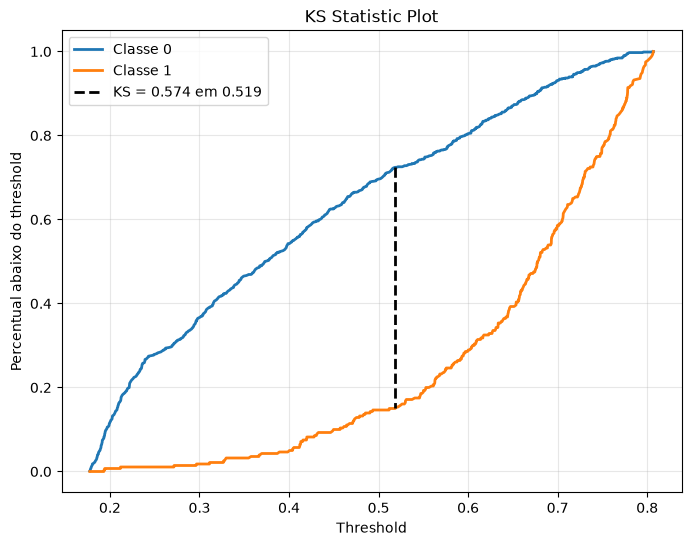

np.float64(0.5742268041237113)

In [55]:
plot_ks_curve(y_val, model.predict_proba(X_val)[:, 1])

### Teste

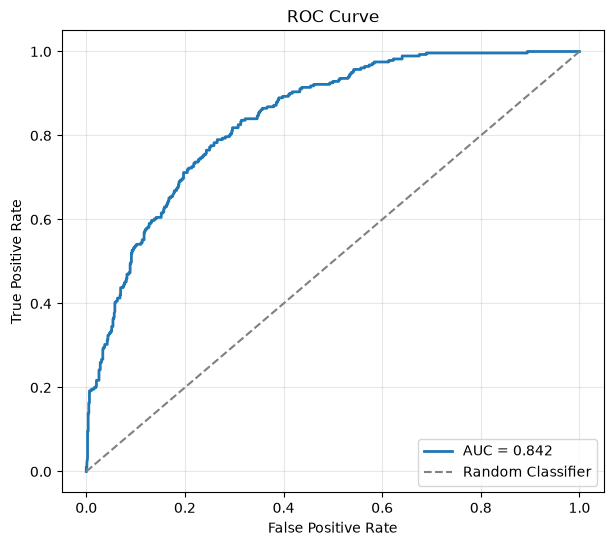

,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.73,0.5,0.8,0.61,0.84


In [56]:
metrics = evaluate_model(model, X_test, y_test, plot=True)
metrics

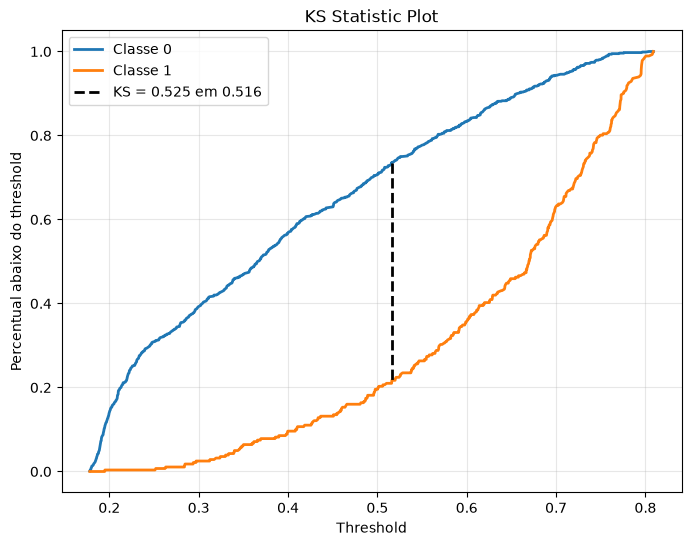

In [57]:
plot_ks_curve(y_test, model.predict_proba(X_test)[:, 1])
y_pred = model.predict_proba(X_test)[:, 1]

In [59]:
y_pred = y_pred > 0.5
y_pred

array([ True, False, False, ..., False, False,  True], shape=(1057,))

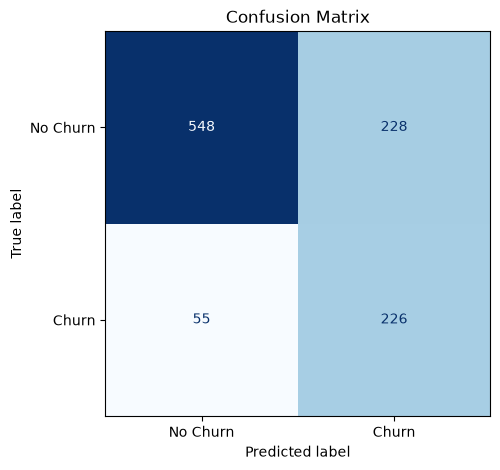

In [60]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    cmap='Blues',
    colorbar=False,
    ax=ax
)

plt.title('Confusion Matrix')
plt.grid(False)
plt.show()

# LGBM

## Optuna

In [7]:

X_train_cv = pd.concat([X_train, X_val])
y_train_cv = pd.concat([y_train, y_val])

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),

        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10, log=True),

        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 5.0),

        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 5),

        "objective": "binary",
        "metric": "binary_logloss",

        "random_state": 42,
        "verbosity": -1,
        "device": "gpu"
    }

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = []

    for tr, va in skf.split(X_train_cv, y_train_cv):

        model = LGBMClassifier(**params)

        model.fit(
            X_train_cv.iloc[tr],
            y_train_cv.iloc[tr]
        )

        pred = model.predict_proba(
            X_train_cv.iloc[va]
        )[:, 1]

        scores.append(
            ks_score(
                y_train_cv.iloc[va],
                pred
            )
        )

    return np.mean(scores)


study = optuna.create_study(
    study_name="lgbm_gpu",
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=70,
    show_progress_bar=True,
    n_jobs=1
)

best_params = study.best_params

[I 2026-07-03 15:35:08,821] A new study created in memory with name: lgbm_gpu
Best trial: 0. Best value: 0.554381:   1%|▏         | 1/70 [00:05<06:26,  5.60s/it]

[I 2026-07-03 15:35:14,425] Trial 0 finished with value: 0.5543810641119329 and parameters: {'n_estimators': 323, 'learning_rate': 0.09367832402945503, 'num_leaves': 161, 'max_depth': 5, 'min_child_samples': 92, 'subsample': 0.852931069545732, 'colsample_bytree': 0.7203510107107165, 'reg_alpha': 0.13557868060047187, 'reg_lambda': 1.4290246065038972, 'min_split_gain': 3.8955553547344737, 'scale_pos_weight': 0.6099104393066381}. Best is trial 0 with value: 0.5543810641119329.


Best trial: 0. Best value: 0.554381:   3%|▎         | 2/70 [00:08<04:40,  4.13s/it]

[I 2026-07-03 15:35:17,521] Trial 1 finished with value: 0.552885709379731 and parameters: {'n_estimators': 393, 'learning_rate': 0.006565397841257491, 'num_leaves': 144, 'max_depth': 3, 'min_child_samples': 23, 'subsample': 0.9726263784683756, 'colsample_bytree': 0.6638618503357108, 'reg_alpha': 0.008037468263161244, 'reg_lambda': 2.495162134935427e-05, 'min_split_gain': 2.801319624689009, 'scale_pos_weight': 1.056007464043071}. Best is trial 0 with value: 0.5543810641119329.


Best trial: 0. Best value: 0.554381:   4%|▍         | 3/70 [00:09<03:09,  2.82s/it]

[I 2026-07-03 15:35:18,788] Trial 2 finished with value: 0.5459312673484972 and parameters: {'n_estimators': 323, 'learning_rate': 0.1598146537064583, 'num_leaves': 51, 'max_depth': 4, 'min_child_samples': 48, 'subsample': 0.7727885357764346, 'colsample_bytree': 0.9697172572774051, 'reg_alpha': 0.0006706446230554216, 'reg_lambda': 0.011651971826496238, 'min_split_gain': 1.1732331312827649, 'scale_pos_weight': 2.5222976166065876}. Best is trial 0 with value: 0.5543810641119329.


Best trial: 0. Best value: 0.554381:   6%|▌         | 4/70 [00:13<03:17,  2.99s/it]

[I 2026-07-03 15:35:22,048] Trial 3 finished with value: 0.55120077596539 and parameters: {'n_estimators': 153, 'learning_rate': 0.007098052418129337, 'num_leaves': 180, 'max_depth': 5, 'min_child_samples': 56, 'subsample': 0.7952047985145981, 'colsample_bytree': 0.9693988433341116, 'reg_alpha': 1.2186272675404024, 'reg_lambda': 7.871592635048094e-05, 'min_split_gain': 3.0594900859342062, 'scale_pos_weight': 4.111539642473045}. Best is trial 0 with value: 0.5543810641119329.


Best trial: 0. Best value: 0.554381:   7%|▋         | 5/70 [00:17<03:37,  3.34s/it]

[I 2026-07-03 15:35:26,011] Trial 4 finished with value: 0.5516706873163888 and parameters: {'n_estimators': 499, 'learning_rate': 0.018916833845699695, 'num_leaves': 209, 'max_depth': 7, 'min_child_samples': 55, 'subsample': 0.9283866384200606, 'colsample_bytree': 0.7608916597620436, 'reg_alpha': 0.4837839287653197, 'reg_lambda': 9.221597869348504e-05, 'min_split_gain': 4.080163076489544, 'scale_pos_weight': 2.6529296675608807}. Best is trial 0 with value: 0.5543810641119329.


Best trial: 0. Best value: 0.554381:   9%|▊         | 6/70 [00:20<03:41,  3.46s/it]

[I 2026-07-03 15:35:29,700] Trial 5 finished with value: 0.5445683676166437 and parameters: {'n_estimators': 229, 'learning_rate': 0.005119749006024436, 'num_leaves': 134, 'max_depth': 8, 'min_child_samples': 89, 'subsample': 0.8773832407974078, 'colsample_bytree': 0.9587091674572772, 'reg_alpha': 0.012253190309211796, 'reg_lambda': 6.003948652981561, 'min_split_gain': 2.936590439093867, 'scale_pos_weight': 0.8086774542826793}. Best is trial 0 with value: 0.5543810641119329.


Best trial: 0. Best value: 0.554381:  10%|█         | 7/70 [00:22<02:59,  2.85s/it]

[I 2026-07-03 15:35:31,288] Trial 6 finished with value: 0.5397980783725862 and parameters: {'n_estimators': 225, 'learning_rate': 0.17276663250864693, 'num_leaves': 91, 'max_depth': 8, 'min_child_samples': 25, 'subsample': 0.7276061320799154, 'colsample_bytree': 0.8392370701824667, 'reg_alpha': 0.15655073110987672, 'reg_lambda': 0.5627913113738305, 'min_split_gain': 1.2358354098679163, 'scale_pos_weight': 1.2173109118126155}. Best is trial 0 with value: 0.5543810641119329.


Best trial: 7. Best value: 0.555104:  11%|█▏        | 8/70 [00:24<02:32,  2.45s/it]

[I 2026-07-03 15:35:32,889] Trial 7 finished with value: 0.5551042814893343 and parameters: {'n_estimators': 462, 'learning_rate': 0.08596397764846245, 'num_leaves': 15, 'max_depth': 10, 'min_child_samples': 53, 'subsample': 0.9859264393405467, 'colsample_bytree': 0.6901143148810236, 'reg_alpha': 0.028892268332358792, 'reg_lambda': 0.007036479974604163, 'min_split_gain': 4.22858276189518, 'scale_pos_weight': 4.625623689833157}. Best is trial 7 with value: 0.5551042814893343.


Best trial: 7. Best value: 0.555104:  13%|█▎        | 9/70 [00:26<02:30,  2.47s/it]

[I 2026-07-03 15:35:35,403] Trial 8 finished with value: 0.5519796921916397 and parameters: {'n_estimators': 438, 'learning_rate': 0.06429436038960389, 'num_leaves': 16, 'max_depth': 7, 'min_child_samples': 26, 'subsample': 0.8649357075832554, 'colsample_bytree': 0.5197615013726185, 'reg_alpha': 0.9133616132841368, 'reg_lambda': 3.518587699044282, 'min_split_gain': 0.9017424412454628, 'scale_pos_weight': 4.963634975722802}. Best is trial 7 with value: 0.5551042814893343.


Best trial: 7. Best value: 0.555104:  14%|█▍        | 10/70 [00:28<02:15,  2.25s/it]

[I 2026-07-03 15:35:37,171] Trial 9 finished with value: 0.5542096677201244 and parameters: {'n_estimators': 115, 'learning_rate': 0.023130410043399444, 'num_leaves': 232, 'max_depth': 9, 'min_child_samples': 46, 'subsample': 0.7309836131213013, 'colsample_bytree': 0.5007945714247057, 'reg_alpha': 7.109166472458585, 'reg_lambda': 0.013586563256647904, 'min_split_gain': 3.03776989240561, 'scale_pos_weight': 2.465652789683097}. Best is trial 7 with value: 0.5551042814893343.


Best trial: 7. Best value: 0.555104:  16%|█▌        | 11/70 [00:31<02:24,  2.45s/it]

[I 2026-07-03 15:35:40,075] Trial 10 finished with value: 0.5490102025117823 and parameters: {'n_estimators': 499, 'learning_rate': 0.03291111166731057, 'num_leaves': 92, 'max_depth': 10, 'min_child_samples': 73, 'subsample': 0.6126372215829352, 'colsample_bytree': 0.6099175884028066, 'reg_alpha': 2.3470229493612564e-05, 'reg_lambda': 0.002075593041942377, 'min_split_gain': 4.809205307497281, 'scale_pos_weight': 3.778947485088823}. Best is trial 7 with value: 0.5551042814893343.


Best trial: 7. Best value: 0.555104:  17%|█▋        | 12/70 [00:32<02:03,  2.13s/it]

[I 2026-07-03 15:35:41,476] Trial 11 finished with value: 0.5517214836380301 and parameters: {'n_estimators': 336, 'learning_rate': 0.08141589503147484, 'num_leaves': 81, 'max_depth': 5, 'min_child_samples': 100, 'subsample': 0.9862279788344172, 'colsample_bytree': 0.7325429264709246, 'reg_alpha': 0.0223936618755571, 'reg_lambda': 0.2323516324221792, 'min_split_gain': 4.047841682028343, 'scale_pos_weight': 1.762960588468467}. Best is trial 7 with value: 0.5551042814893343.


Best trial: 7. Best value: 0.555104:  19%|█▊        | 13/70 [00:35<02:06,  2.22s/it]

[I 2026-07-03 15:35:43,905] Trial 12 finished with value: 0.5424639514264638 and parameters: {'n_estimators': 317, 'learning_rate': 0.07251942346150736, 'num_leaves': 248, 'max_depth': 10, 'min_child_samples': 6, 'subsample': 0.8713794866487757, 'colsample_bytree': 0.8308733297567197, 'reg_alpha': 0.0009752577740787235, 'reg_lambda': 0.12031936767191272, 'min_split_gain': 4.10137563669085, 'scale_pos_weight': 3.5434387819756523}. Best is trial 7 with value: 0.5551042814893343.


Best trial: 13. Best value: 0.555842:  20%|██        | 14/70 [00:36<01:52,  2.01s/it]

[I 2026-07-03 15:35:45,440] Trial 13 finished with value: 0.5558421702523518 and parameters: {'n_estimators': 411, 'learning_rate': 0.10700546961910747, 'num_leaves': 15, 'max_depth': 6, 'min_child_samples': 77, 'subsample': 0.9317490037160725, 'colsample_bytree': 0.6640219979051312, 'reg_alpha': 0.1171238798082638, 'reg_lambda': 0.001038797196817395, 'min_split_gain': 4.655014141158071, 'scale_pos_weight': 4.8313386291157006}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  21%|██▏       | 15/70 [00:38<01:48,  1.98s/it]

[I 2026-07-03 15:35:47,338] Trial 14 finished with value: 0.551728345181646 and parameters: {'n_estimators': 423, 'learning_rate': 0.05317641528740488, 'num_leaves': 17, 'max_depth': 6, 'min_child_samples': 69, 'subsample': 0.9310679636190486, 'colsample_bytree': 0.6033553062346229, 'reg_alpha': 0.001399358404999264, 'reg_lambda': 0.0007963030855010944, 'min_split_gain': 4.935410441380828, 'scale_pos_weight': 4.798855145979599}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  23%|██▎       | 16/70 [00:39<01:35,  1.77s/it]

[I 2026-07-03 15:35:48,610] Trial 15 finished with value: 0.5480169295299926 and parameters: {'n_estimators': 388, 'learning_rate': 0.12932574324522655, 'num_leaves': 52, 'max_depth': 3, 'min_child_samples': 73, 'subsample': 0.9967665614334208, 'colsample_bytree': 0.6562917045654356, 'reg_alpha': 0.06437015426731175, 'reg_lambda': 0.0009703434595122676, 'min_split_gain': 2.213649530929444, 'scale_pos_weight': 4.478905102995952}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  24%|██▍       | 17/70 [00:44<02:12,  2.50s/it]

[I 2026-07-03 15:35:52,830] Trial 16 finished with value: 0.5492796178070035 and parameters: {'n_estimators': 453, 'learning_rate': 0.044292815040995595, 'num_leaves': 48, 'max_depth': 9, 'min_child_samples': 80, 'subsample': 0.9369814920900327, 'colsample_bytree': 0.8114001742281195, 'reg_alpha': 7.745455476459142, 'reg_lambda': 0.0190308808313935, 'min_split_gain': 0.14669050055173605, 'scale_pos_weight': 3.289326443999318}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  26%|██▌       | 18/70 [00:45<01:53,  2.18s/it]

[I 2026-07-03 15:35:54,256] Trial 17 finished with value: 0.5488212189707518 and parameters: {'n_estimators': 379, 'learning_rate': 0.11178107350186602, 'num_leaves': 15, 'max_depth': 7, 'min_child_samples': 60, 'subsample': 0.9238235857460008, 'colsample_bytree': 0.5704265593111181, 'reg_alpha': 7.72637137711283e-05, 'reg_lambda': 0.0024364085170425595, 'min_split_gain': 4.497389930230221, 'scale_pos_weight': 4.365007207838298}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  27%|██▋       | 19/70 [00:47<01:41,  2.00s/it]

[I 2026-07-03 15:35:55,825] Trial 18 finished with value: 0.5485297393175449 and parameters: {'n_estimators': 464, 'learning_rate': 0.18764832770182746, 'num_leaves': 65, 'max_depth': 9, 'min_child_samples': 39, 'subsample': 0.8110905138941806, 'colsample_bytree': 0.6795832095189882, 'reg_alpha': 0.003677393628472363, 'reg_lambda': 0.00029599937161750545, 'min_split_gain': 3.5343643516254954, 'scale_pos_weight': 4.082917372236552}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  29%|██▊       | 20/70 [00:49<01:47,  2.15s/it]

[I 2026-07-03 15:35:58,319] Trial 19 finished with value: 0.5509040973840206 and parameters: {'n_estimators': 372, 'learning_rate': 0.037828802204798694, 'num_leaves': 115, 'max_depth': 6, 'min_child_samples': 82, 'subsample': 0.9652437132459429, 'colsample_bytree': 0.8890129942723923, 'reg_alpha': 0.0500219786724367, 'reg_lambda': 0.04859344486791156, 'min_split_gain': 3.569838764545674, 'scale_pos_weight': 3.148050437008778}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  30%|███       | 21/70 [00:55<02:39,  3.25s/it]

[I 2026-07-03 15:36:04,146] Trial 20 finished with value: 0.5486500134543872 and parameters: {'n_estimators': 268, 'learning_rate': 0.013848628141176643, 'num_leaves': 40, 'max_depth': 8, 'min_child_samples': 36, 'subsample': 0.8979290847646113, 'colsample_bytree': 0.7654463775412679, 'reg_alpha': 0.3134103816248965, 'reg_lambda': 1.060816520768996e-05, 'min_split_gain': 4.502739429183938, 'scale_pos_weight': 4.634639498228139}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  31%|███▏      | 22/70 [00:56<02:08,  2.68s/it]

[I 2026-07-03 15:36:05,501] Trial 21 finished with value: 0.5553848059570055 and parameters: {'n_estimators': 282, 'learning_rate': 0.09954474404151421, 'num_leaves': 171, 'max_depth': 5, 'min_child_samples': 100, 'subsample': 0.8382111857358103, 'colsample_bytree': 0.7100383264671782, 'reg_alpha': 0.0996481304801833, 'reg_lambda': 0.8801363344231158, 'min_split_gain': 3.58901636597494, 'scale_pos_weight': 1.7762553938328127}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  33%|███▎      | 23/70 [00:57<01:45,  2.25s/it]

[I 2026-07-03 15:36:06,758] Trial 22 finished with value: 0.5528079961424662 and parameters: {'n_estimators': 277, 'learning_rate': 0.11473645232974591, 'num_leaves': 194, 'max_depth': 4, 'min_child_samples': 100, 'subsample': 0.8211211815179765, 'colsample_bytree': 0.7029998675845028, 'reg_alpha': 0.027581869293793082, 'reg_lambda': 0.008621901919759048, 'min_split_gain': 2.40393556211718, 'scale_pos_weight': 1.8373986112153196}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  34%|███▍      | 24/70 [00:59<01:31,  2.00s/it]

[I 2026-07-03 15:36:08,153] Trial 23 finished with value: 0.5546345539654081 and parameters: {'n_estimators': 172, 'learning_rate': 0.05679730573802418, 'num_leaves': 106, 'max_depth': 6, 'min_child_samples': 65, 'subsample': 0.6616897215584554, 'colsample_bytree': 0.6163761209410142, 'reg_alpha': 2.432371779459979, 'reg_lambda': 0.06148423619474484, 'min_split_gain': 3.5316746808856294, 'scale_pos_weight': 1.789430026611054}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 13. Best value: 0.555842:  36%|███▌      | 25/70 [01:00<01:22,  1.83s/it]

[I 2026-07-03 15:36:09,579] Trial 24 finished with value: 0.552797640407087 and parameters: {'n_estimators': 428, 'learning_rate': 0.0880436350219623, 'num_leaves': 34, 'max_depth': 4, 'min_child_samples': 82, 'subsample': 0.9557386668702823, 'colsample_bytree': 0.7779847639089972, 'reg_alpha': 0.11949812447653532, 'reg_lambda': 0.00018506166383560458, 'min_split_gain': 4.457816041419396, 'scale_pos_weight': 2.9181708427895696}. Best is trial 13 with value: 0.5558421702523518.


Best trial: 25. Best value: 0.556217:  37%|███▋      | 26/70 [01:02<01:15,  1.71s/it]

[I 2026-07-03 15:36:11,034] Trial 25 finished with value: 0.5562169577955018 and parameters: {'n_estimators': 470, 'learning_rate': 0.13424789197749487, 'num_leaves': 68, 'max_depth': 5, 'min_child_samples': 91, 'subsample': 0.8356320616461858, 'colsample_bytree': 0.6471407105936882, 'reg_alpha': 0.0033170831107903064, 'reg_lambda': 0.00385808965169648, 'min_split_gain': 3.7242737608234555, 'scale_pos_weight': 4.0150286656327925}. Best is trial 25 with value: 0.5562169577955018.


Best trial: 25. Best value: 0.556217:  39%|███▊      | 27/70 [01:03<01:08,  1.60s/it]

[I 2026-07-03 15:36:12,375] Trial 26 finished with value: 0.5488722866547011 and parameters: {'n_estimators': 353, 'learning_rate': 0.1311813636091222, 'num_leaves': 72, 'max_depth': 5, 'min_child_samples': 91, 'subsample': 0.7570361544476841, 'colsample_bytree': 0.5474754811702627, 'reg_alpha': 0.00025557578505687586, 'reg_lambda': 0.6767405166313218, 'min_split_gain': 3.610937846915923, 'scale_pos_weight': 3.9009647025793317}. Best is trial 25 with value: 0.5562169577955018.


Best trial: 25. Best value: 0.556217:  40%|████      | 28/70 [01:04<01:05,  1.55s/it]

[I 2026-07-03 15:36:13,811] Trial 27 finished with value: 0.5533218417174698 and parameters: {'n_estimators': 294, 'learning_rate': 0.13914512015992042, 'num_leaves': 133, 'max_depth': 6, 'min_child_samples': 94, 'subsample': 0.8437782754752858, 'colsample_bytree': 0.6363100547580294, 'reg_alpha': 0.004436602332015412, 'reg_lambda': 0.0005912845502890718, 'min_split_gain': 1.847090940941543, 'scale_pos_weight': 2.127761185996145}. Best is trial 25 with value: 0.5562169577955018.


Best trial: 25. Best value: 0.556217:  41%|████▏     | 29/70 [01:06<00:58,  1.43s/it]

[I 2026-07-03 15:36:14,940] Trial 28 finished with value: 0.5513813581552236 and parameters: {'n_estimators': 221, 'learning_rate': 0.10612222640564035, 'num_leaves': 170, 'max_depth': 4, 'min_child_samples': 85, 'subsample': 0.9044656078157653, 'colsample_bytree': 0.5723380613625166, 'reg_alpha': 1.2442839920890367e-05, 'reg_lambda': 0.0026783706585165306, 'min_split_gain': 3.223779588812989, 'scale_pos_weight': 1.4387234345206588}. Best is trial 25 with value: 0.5562169577955018.


Best trial: 25. Best value: 0.556217:  43%|████▎     | 30/70 [01:07<00:55,  1.40s/it]

[I 2026-07-03 15:36:16,276] Trial 29 finished with value: 0.5477119746675491 and parameters: {'n_estimators': 405, 'learning_rate': 0.1904858870322014, 'num_leaves': 110, 'max_depth': 5, 'min_child_samples': 77, 'subsample': 0.8254841626687209, 'colsample_bytree': 0.7344410385496452, 'reg_alpha': 0.00023685815523619957, 'reg_lambda': 2.9038071732435475, 'min_split_gain': 2.5752608853437833, 'scale_pos_weight': 3.5351626742651225}. Best is trial 25 with value: 0.5562169577955018.


Best trial: 30. Best value: 0.557247:  44%|████▍     | 31/70 [01:08<00:53,  1.37s/it]

[I 2026-07-03 15:36:17,595] Trial 30 finished with value: 0.557246615825931 and parameters: {'n_estimators': 186, 'learning_rate': 0.10087787284165073, 'num_leaves': 219, 'max_depth': 5, 'min_child_samples': 93, 'subsample': 0.8417537801265982, 'colsample_bytree': 0.7264875067682968, 'reg_alpha': 0.1950173455864767, 'reg_lambda': 9.39632882750745, 'min_split_gain': 3.796270154227824, 'scale_pos_weight': 4.998782885158042}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  46%|████▌     | 32/70 [01:10<00:53,  1.40s/it]

[I 2026-07-03 15:36:19,049] Trial 31 finished with value: 0.5518531965279487 and parameters: {'n_estimators': 159, 'learning_rate': 0.08775128006435434, 'num_leaves': 214, 'max_depth': 5, 'min_child_samples': 94, 'subsample': 0.794295111167229, 'colsample_bytree': 0.7125854047929907, 'reg_alpha': 0.20142464470946922, 'reg_lambda': 0.8231108857968176, 'min_split_gain': 3.783700062799235, 'scale_pos_weight': 4.930736437336891}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  47%|████▋     | 33/70 [01:11<00:54,  1.48s/it]

[I 2026-07-03 15:36:20,711] Trial 32 finished with value: 0.5556795861564293 and parameters: {'n_estimators': 193, 'learning_rate': 0.06377690211801895, 'num_leaves': 150, 'max_depth': 6, 'min_child_samples': 88, 'subsample': 0.8454053641793999, 'colsample_bytree': 0.651913387237095, 'reg_alpha': 0.09039660186781466, 'reg_lambda': 9.901871344720323, 'min_split_gain': 3.3094676133742515, 'scale_pos_weight': 4.317842799522959}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  49%|████▊     | 34/70 [01:13<00:55,  1.54s/it]

[I 2026-07-03 15:36:22,387] Trial 33 finished with value: 0.551328375961177 and parameters: {'n_estimators': 198, 'learning_rate': 0.0664502065443216, 'num_leaves': 140, 'max_depth': 6, 'min_child_samples': 89, 'subsample': 0.8872251062299464, 'colsample_bytree': 0.6534963643404019, 'reg_alpha': 0.009628392390603457, 'reg_lambda': 8.251799205369798, 'min_split_gain': 3.2235597254091006, 'scale_pos_weight': 4.287806306386885}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  50%|█████     | 35/70 [01:14<00:50,  1.45s/it]

[I 2026-07-03 15:36:23,648] Trial 34 finished with value: 0.5508711397522872 and parameters: {'n_estimators': 111, 'learning_rate': 0.04640956536872632, 'num_leaves': 188, 'max_depth': 3, 'min_child_samples': 76, 'subsample': 0.7619629278843244, 'colsample_bytree': 0.6397672065624144, 'reg_alpha': 0.4927770186405718, 'reg_lambda': 2.2088356892139194, 'min_split_gain': 4.603510475404245, 'scale_pos_weight': 4.194714184672097}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  51%|█████▏    | 36/70 [01:16<00:48,  1.42s/it]

[I 2026-07-03 15:36:24,998] Trial 35 finished with value: 0.5516999620354388 and parameters: {'n_estimators': 253, 'learning_rate': 0.1380145792413868, 'num_leaves': 246, 'max_depth': 7, 'min_child_samples': 86, 'subsample': 0.8515115397126282, 'colsample_bytree': 0.5849936606115915, 'reg_alpha': 1.6695122892422298, 'reg_lambda': 0.19991523877785863, 'min_split_gain': 3.8914205105233335, 'scale_pos_weight': 4.642835933324942}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  53%|█████▎    | 37/70 [01:17<00:45,  1.36s/it]

[I 2026-07-03 15:36:26,228] Trial 36 finished with value: 0.5541632988839091 and parameters: {'n_estimators': 131, 'learning_rate': 0.1549272151059554, 'num_leaves': 153, 'max_depth': 6, 'min_child_samples': 67, 'subsample': 0.7845377081611855, 'colsample_bytree': 0.6722397426031327, 'reg_alpha': 0.5640265248388093, 'reg_lambda': 6.528523971178335e-05, 'min_split_gain': 3.3165997180435447, 'scale_pos_weight': 3.9661982021266478}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  54%|█████▍    | 38/70 [01:19<00:49,  1.54s/it]

[I 2026-07-03 15:36:28,172] Trial 37 finished with value: 0.5517625837548922 and parameters: {'n_estimators': 188, 'learning_rate': 0.033771563448666594, 'num_leaves': 221, 'max_depth': 4, 'min_child_samples': 93, 'subsample': 0.9087761778349172, 'colsample_bytree': 0.7428783624768976, 'reg_alpha': 3.2070643955222833, 'reg_lambda': 6.7586222343453395, 'min_split_gain': 2.7036983778881956, 'scale_pos_weight': 4.450740382492789}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  56%|█████▌    | 39/70 [01:21<00:50,  1.63s/it]

[I 2026-07-03 15:36:30,028] Trial 38 finished with value: 0.5519859305391654 and parameters: {'n_estimators': 473, 'learning_rate': 0.06947300691881608, 'num_leaves': 196, 'max_depth': 7, 'min_child_samples': 95, 'subsample': 0.7393610104558724, 'colsample_bytree': 0.6352958182065013, 'reg_alpha': 0.0024832437136414675, 'reg_lambda': 2.5898607194395385e-05, 'min_split_gain': 4.271548373838308, 'scale_pos_weight': 3.6236121400306724}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  57%|█████▋    | 40/70 [01:23<00:51,  1.72s/it]

[I 2026-07-03 15:36:31,950] Trial 39 finished with value: 0.5519129076392646 and parameters: {'n_estimators': 247, 'learning_rate': 0.055568434321028475, 'num_leaves': 127, 'max_depth': 6, 'min_child_samples': 84, 'subsample': 0.6817719965257246, 'colsample_bytree': 0.7837765490833859, 'reg_alpha': 0.014177785852221621, 'reg_lambda': 1.494938142924826, 'min_split_gain': 3.9624401161511535, 'scale_pos_weight': 4.7930835228298605}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  59%|█████▊    | 41/70 [01:24<00:46,  1.61s/it]

[I 2026-07-03 15:36:33,313] Trial 40 finished with value: 0.5498433760871551 and parameters: {'n_estimators': 146, 'learning_rate': 0.07827233650948197, 'num_leaves': 150, 'max_depth': 5, 'min_child_samples': 61, 'subsample': 0.8059989053624687, 'colsample_bytree': 0.5418548987006497, 'reg_alpha': 0.2249517267587847, 'reg_lambda': 4.436844744964048, 'min_split_gain': 4.998077610601882, 'scale_pos_weight': 4.177647156452338}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  60%|██████    | 42/70 [01:25<00:41,  1.50s/it]

[I 2026-07-03 15:36:34,545] Trial 41 finished with value: 0.5517715317550163 and parameters: {'n_estimators': 204, 'learning_rate': 0.09953830869332907, 'num_leaves': 165, 'max_depth': 5, 'min_child_samples': 98, 'subsample': 0.8371571101772155, 'colsample_bytree': 0.6983027526136211, 'reg_alpha': 0.06206652288290846, 'reg_lambda': 1.5628825884681818, 'min_split_gain': 2.9092091642497597, 'scale_pos_weight': 0.7692760792520092}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  61%|██████▏   | 43/70 [01:27<00:41,  1.54s/it]

[I 2026-07-03 15:36:36,168] Trial 42 finished with value: 0.5534736324941727 and parameters: {'n_estimators': 487, 'learning_rate': 0.10546621527368012, 'num_leaves': 175, 'max_depth': 5, 'min_child_samples': 87, 'subsample': 0.8711577298182056, 'colsample_bytree': 0.6815152185852683, 'reg_alpha': 0.09111681567267986, 'reg_lambda': 0.3578893564727166, 'min_split_gain': 3.6851048688159636, 'scale_pos_weight': 4.961969944878739}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  63%|██████▎   | 44/70 [01:28<00:36,  1.41s/it]

[I 2026-07-03 15:36:37,279] Trial 43 finished with value: 0.5528794896688385 and parameters: {'n_estimators': 310, 'learning_rate': 0.1572261823938771, 'num_leaves': 205, 'max_depth': 5, 'min_child_samples': 89, 'subsample': 0.8456717324363421, 'colsample_bytree': 0.7034350606041703, 'reg_alpha': 1.1245598121323133, 'reg_lambda': 8.768506343641674, 'min_split_gain': 3.3272978755053675, 'scale_pos_weight': 0.5151048095214614}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  64%|██████▍   | 45/70 [01:29<00:32,  1.31s/it]

[I 2026-07-03 15:36:38,347] Trial 44 finished with value: 0.5521284251138738 and parameters: {'n_estimators': 169, 'learning_rate': 0.12569082161773404, 'num_leaves': 223, 'max_depth': 4, 'min_child_samples': 78, 'subsample': 0.830444355823198, 'colsample_bytree': 0.7217443815895672, 'reg_alpha': 0.36356369433509433, 'reg_lambda': 3.748863340128312, 'min_split_gain': 4.28318765606697, 'scale_pos_weight': 4.575548854554828}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  66%|██████▌   | 46/70 [01:32<00:42,  1.76s/it]

[I 2026-07-03 15:36:41,153] Trial 45 finished with value: 0.5519045728013039 and parameters: {'n_estimators': 403, 'learning_rate': 0.02589271577202069, 'num_leaves': 93, 'max_depth': 6, 'min_child_samples': 95, 'subsample': 0.88693167493246, 'colsample_bytree': 0.7527261373193888, 'reg_alpha': 0.039648564620565645, 'reg_lambda': 0.003816644183981873, 'min_split_gain': 4.680006350531412, 'scale_pos_weight': 2.6620023855511814}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  67%|██████▋   | 47/70 [01:34<00:41,  1.82s/it]

[I 2026-07-03 15:36:43,119] Trial 46 finished with value: 0.5509575726101238 and parameters: {'n_estimators': 349, 'learning_rate': 0.06230313480817944, 'num_leaves': 30, 'max_depth': 5, 'min_child_samples': 100, 'subsample': 0.862823383273472, 'colsample_bytree': 0.6171410391919657, 'reg_alpha': 0.016862684221950554, 'reg_lambda': 0.03046015356218394, 'min_split_gain': 3.865092782763809, 'scale_pos_weight': 4.803760615483599}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  69%|██████▊   | 48/70 [01:39<01:05,  2.96s/it]

[I 2026-07-03 15:36:48,732] Trial 47 finished with value: 0.5503877390953088 and parameters: {'n_estimators': 238, 'learning_rate': 0.008659385401312125, 'num_leaves': 62, 'max_depth': 7, 'min_child_samples': 71, 'subsample': 0.8031692448046912, 'colsample_bytree': 0.6605048707233846, 'reg_alpha': 0.12879196154648778, 'reg_lambda': 1.1077051274890963, 'min_split_gain': 3.0800640303075686, 'scale_pos_weight': 3.7284783502207737}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  70%|███████   | 49/70 [01:41<00:52,  2.49s/it]

[I 2026-07-03 15:36:50,125] Trial 48 finished with value: 0.5514469499476785 and parameters: {'n_estimators': 451, 'learning_rate': 0.0941908822827623, 'num_leaves': 237, 'max_depth': 6, 'min_child_samples': 90, 'subsample': 0.7781720544657881, 'colsample_bytree': 0.9966438696586102, 'reg_alpha': 0.007798294672924309, 'reg_lambda': 0.389093741369385, 'min_split_gain': 4.151779881821078, 'scale_pos_weight': 1.2690074475289796}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  71%|███████▏  | 50/70 [01:42<00:41,  2.07s/it]

[I 2026-07-03 15:36:51,225] Trial 49 finished with value: 0.5513514623638284 and parameters: {'n_estimators': 134, 'learning_rate': 0.07958430662068174, 'num_leaves': 123, 'max_depth': 3, 'min_child_samples': 74, 'subsample': 0.9452357017199424, 'colsample_bytree': 0.8741823056937976, 'reg_alpha': 0.661738321278926, 'reg_lambda': 0.00028761484407161333, 'min_split_gain': 1.9981906950959256, 'scale_pos_weight': 2.167843648817981}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  73%|███████▎  | 51/70 [01:43<00:34,  1.79s/it]

[I 2026-07-03 15:36:52,374] Trial 50 finished with value: 0.5468332140711919 and parameters: {'n_estimators': 217, 'learning_rate': 0.15803556513845582, 'num_leaves': 180, 'max_depth': 4, 'min_child_samples': 80, 'subsample': 0.9149778452547868, 'colsample_bytree': 0.5939628582060262, 'reg_alpha': 0.09106709284054516, 'reg_lambda': 0.004972313754224066, 'min_split_gain': 3.438506367082499, 'scale_pos_weight': 3.2824190287193122}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  74%|███████▍  | 52/70 [01:45<00:35,  1.98s/it]

[I 2026-07-03 15:36:54,776] Trial 51 finished with value: 0.5520977606498448 and parameters: {'n_estimators': 477, 'learning_rate': 0.04717015885370059, 'num_leaves': 26, 'max_depth': 8, 'min_child_samples': 51, 'subsample': 0.979877568913244, 'colsample_bytree': 0.69038034954999, 'reg_alpha': 0.03737239598043078, 'reg_lambda': 0.001269414324004154, 'min_split_gain': 4.327704547300027, 'scale_pos_weight': 4.387316660747349}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  76%|███████▌  | 53/70 [01:47<00:33,  1.97s/it]

[I 2026-07-03 15:36:56,729] Trial 52 finished with value: 0.5438325961352184 and parameters: {'n_estimators': 437, 'learning_rate': 0.09418206236224949, 'num_leaves': 43, 'max_depth': 10, 'min_child_samples': 15, 'subsample': 0.9925500145113489, 'colsample_bytree': 0.7222143324852055, 'reg_alpha': 0.029272160693145186, 'reg_lambda': 0.0012287542802777401, 'min_split_gain': 4.752116429185462, 'scale_pos_weight': 4.700347095508782}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  77%|███████▋  | 54/70 [01:50<00:32,  2.03s/it]

[I 2026-07-03 15:36:58,894] Trial 53 finished with value: 0.5469231609270238 and parameters: {'n_estimators': 500, 'learning_rate': 0.07289913397547451, 'num_leaves': 52, 'max_depth': 8, 'min_child_samples': 55, 'subsample': 0.9572725754816475, 'colsample_bytree': 0.6689286225585651, 'reg_alpha': 0.005570658721837354, 'reg_lambda': 0.006710048506848159, 'min_split_gain': 4.058609361377832, 'scale_pos_weight': 4.474099564792942}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  79%|███████▊  | 55/70 [01:51<00:28,  1.90s/it]

[I 2026-07-03 15:37:00,489] Trial 54 finished with value: 0.5518125788090282 and parameters: {'n_estimators': 452, 'learning_rate': 0.10997421962184198, 'num_leaves': 22, 'max_depth': 9, 'min_child_samples': 43, 'subsample': 0.8627372246045542, 'colsample_bytree': 0.6458876242493402, 'reg_alpha': 0.0020729193446361554, 'reg_lambda': 0.013379517066773823, 'min_split_gain': 3.7628306036141836, 'scale_pos_weight': 4.057150974411189}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  80%|████████  | 56/70 [01:53<00:24,  1.74s/it]

[I 2026-07-03 15:37:01,873] Trial 55 finished with value: 0.5503808028666546 and parameters: {'n_estimators': 409, 'learning_rate': 0.12163042637801072, 'num_leaves': 80, 'max_depth': 4, 'min_child_samples': 95, 'subsample': 0.972012171983646, 'colsample_bytree': 0.8037512176993711, 'reg_alpha': 0.22873061701884326, 'reg_lambda': 0.09218085968965378, 'min_split_gain': 4.150558530683132, 'scale_pos_weight': 4.941656005082086}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  81%|████████▏ | 57/70 [01:54<00:23,  1.78s/it]

[I 2026-07-03 15:37:03,730] Trial 56 finished with value: 0.5476011723879715 and parameters: {'n_estimators': 422, 'learning_rate': 0.0859679518359786, 'num_leaves': 37, 'max_depth': 5, 'min_child_samples': 33, 'subsample': 0.8218226665512305, 'colsample_bytree': 0.6266884472390712, 'reg_alpha': 0.0005318266249337935, 'reg_lambda': 0.021623938375998845, 'min_split_gain': 3.041691971805029, 'scale_pos_weight': 4.5918859746784895}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  83%|████████▎ | 58/70 [01:56<00:22,  1.86s/it]

[I 2026-07-03 15:37:05,771] Trial 57 finished with value: 0.5534410449942867 and parameters: {'n_estimators': 463, 'learning_rate': 0.060088490583400454, 'num_leaves': 99, 'max_depth': 7, 'min_child_samples': 97, 'subsample': 0.8843355902586376, 'colsample_bytree': 0.6786607295315366, 'reg_alpha': 0.0780490420824765, 'reg_lambda': 0.0003947638934197162, 'min_split_gain': 4.4606674236169495, 'scale_pos_weight': 4.315905349293345}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  84%|████████▍ | 59/70 [01:58<00:19,  1.76s/it]

[I 2026-07-03 15:37:07,309] Trial 58 finished with value: 0.5423779890243494 and parameters: {'n_estimators': 287, 'learning_rate': 0.16881958068869107, 'num_leaves': 255, 'max_depth': 6, 'min_child_samples': 29, 'subsample': 0.9412096781959247, 'colsample_bytree': 0.7550267138000614, 'reg_alpha': 0.021466022676779682, 'reg_lambda': 0.0017857139288786116, 'min_split_gain': 3.4095785441296087, 'scale_pos_weight': 4.784500507393778}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  86%|████████▌ | 60/70 [02:00<00:18,  1.82s/it]

[I 2026-07-03 15:37:09,265] Trial 59 finished with value: 0.5528836165212083 and parameters: {'n_estimators': 183, 'learning_rate': 0.04005626300105293, 'num_leaves': 59, 'max_depth': 5, 'min_child_samples': 83, 'subsample': 0.7084233150639745, 'colsample_bytree': 0.7305241304955724, 'reg_alpha': 0.14313143383177124, 'reg_lambda': 5.327074043499417, 'min_split_gain': 3.684726079982585, 'scale_pos_weight': 3.844486812136084}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  87%|████████▋ | 61/70 [02:02<00:17,  1.97s/it]

[I 2026-07-03 15:37:11,574] Trial 60 finished with value: 0.5385399746150279 and parameters: {'n_estimators': 354, 'learning_rate': 0.14034062382375037, 'num_leaves': 21, 'max_depth': 10, 'min_child_samples': 91, 'subsample': 0.9231254926448147, 'colsample_bytree': 0.7106648398312078, 'reg_alpha': 0.04601742182476684, 'reg_lambda': 0.0001346288161679184, 'min_split_gain': 0.3869571522709543, 'scale_pos_weight': 4.994515203546067}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  89%|████████▊ | 62/70 [02:03<00:13,  1.73s/it]

[I 2026-07-03 15:37:12,755] Trial 61 finished with value: 0.5532703511004438 and parameters: {'n_estimators': 162, 'learning_rate': 0.07360570634730637, 'num_leaves': 108, 'max_depth': 6, 'min_child_samples': 63, 'subsample': 0.6147347785539555, 'colsample_bytree': 0.6171668162989891, 'reg_alpha': 3.4197144486576763, 'reg_lambda': 0.055349994720245765, 'min_split_gain': 3.5303741892834775, 'scale_pos_weight': 1.681146492770659}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  90%|█████████ | 63/70 [02:05<00:12,  1.72s/it]

[I 2026-07-03 15:37:14,447] Trial 62 finished with value: 0.5529408228289974 and parameters: {'n_estimators': 174, 'learning_rate': 0.052395076266214737, 'num_leaves': 150, 'max_depth': 6, 'min_child_samples': 68, 'subsample': 0.6474127352899353, 'colsample_bytree': 0.6010788129075145, 'reg_alpha': 0.2902208302448453, 'reg_lambda': 2.164453490790173, 'min_split_gain': 3.1581140169506456, 'scale_pos_weight': 2.1512787608778545}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  91%|█████████▏| 64/70 [02:06<00:09,  1.55s/it]

[I 2026-07-03 15:37:15,617] Trial 63 finished with value: 0.5568181930063176 and parameters: {'n_estimators': 212, 'learning_rate': 0.09632165489957634, 'num_leaves': 81, 'max_depth': 6, 'min_child_samples': 51, 'subsample': 0.7055389039022183, 'colsample_bytree': 0.687855425505909, 'reg_alpha': 3.952044678806541, 'reg_lambda': 0.008866584895363218, 'min_split_gain': 3.9581839391688765, 'scale_pos_weight': 1.5917745353523862}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  93%|█████████▎| 65/70 [02:08<00:07,  1.48s/it]

[I 2026-07-03 15:37:16,907] Trial 64 finished with value: 0.556720445172813 and parameters: {'n_estimators': 259, 'learning_rate': 0.11079085302071912, 'num_leaves': 120, 'max_depth': 8, 'min_child_samples': 47, 'subsample': 0.720892820964891, 'colsample_bytree': 0.6926295657988439, 'reg_alpha': 4.359493867605245, 'reg_lambda': 0.008356499555070186, 'min_split_gain': 3.8894979443777675, 'scale_pos_weight': 1.3973612776996502}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  94%|█████████▍| 66/70 [02:09<00:05,  1.34s/it]

[I 2026-07-03 15:37:17,917] Trial 65 finished with value: 0.5550369219098717 and parameters: {'n_estimators': 208, 'learning_rate': 0.12123600963985398, 'num_leaves': 79, 'max_depth': 7, 'min_child_samples': 49, 'subsample': 0.7147829223528094, 'colsample_bytree': 0.657875278937034, 'reg_alpha': 5.532554659821658, 'reg_lambda': 0.00405158644838725, 'min_split_gain': 3.959235193669838, 'scale_pos_weight': 1.103429866893973}. Best is trial 30 with value: 0.557246615825931.


Best trial: 30. Best value: 0.557247:  96%|█████████▌| 67/70 [02:10<00:03,  1.29s/it]

[I 2026-07-03 15:37:19,097] Trial 66 finished with value: 0.5529519338327926 and parameters: {'n_estimators': 266, 'learning_rate': 0.10196909251414109, 'num_leaves': 121, 'max_depth': 7, 'min_child_samples': 44, 'subsample': 0.684451595738104, 'colsample_bytree': 0.694138429982338, 'reg_alpha': 9.114803799878743, 'reg_lambda': 0.00875549217559813, 'min_split_gain': 2.81813813594726, 'scale_pos_weight': 1.4149736614968793}. Best is trial 30 with value: 0.557246615825931.


Best trial: 67. Best value: 0.557992:  97%|█████████▋| 68/70 [02:11<00:02,  1.21s/it]

[I 2026-07-03 15:37:20,107] Trial 67 finished with value: 0.5579922073664914 and parameters: {'n_estimators': 231, 'learning_rate': 0.1442828164640639, 'num_leaves': 161, 'max_depth': 9, 'min_child_samples': 58, 'subsample': 0.7457584495402036, 'colsample_bytree': 0.7757153600324794, 'reg_alpha': 1.5671304164033344, 'reg_lambda': 0.0006848431042827355, 'min_split_gain': 3.8298190056858443, 'scale_pos_weight': 0.838234285104909}. Best is trial 67 with value: 0.5579922073664914.


Best trial: 67. Best value: 0.557992:  99%|█████████▊| 69/70 [02:12<00:01,  1.11s/it]

[I 2026-07-03 15:37:21,011] Trial 68 finished with value: 0.5506859903869199 and parameters: {'n_estimators': 226, 'learning_rate': 0.18220970753418309, 'num_leaves': 138, 'max_depth': 9, 'min_child_samples': 56, 'subsample': 0.749595371108001, 'colsample_bytree': 0.8232854807596788, 'reg_alpha': 1.752606569456065, 'reg_lambda': 0.0007189638538463207, 'min_split_gain': 4.351771577737111, 'scale_pos_weight': 0.8578064496709747}. Best is trial 67 with value: 0.5579922073664914.


Best trial: 67. Best value: 0.557992: 100%|██████████| 70/70 [02:13<00:00,  1.90s/it]

[I 2026-07-03 15:37:21,927] Trial 69 finished with value: 0.5551071747535528 and parameters: {'n_estimators': 238, 'learning_rate': 0.19810731081035157, 'num_leaves': 70, 'max_depth': 9, 'min_child_samples': 38, 'subsample': 0.7196632153105532, 'colsample_bytree': 0.7846663586971433, 'reg_alpha': 3.981390516432326, 'reg_lambda': 0.0005561363879603423, 'min_split_gain': 4.848667743430055, 'scale_pos_weight': 0.7184955575048825}. Best is trial 67 with value: 0.5579922073664914.


In [8]:
model = LGBMClassifier(
    **best_params,
    device="gpu"
)

model.fit(X_train, y_train)


,num_leaves,161
,max_depth,9
,learning_rate,0.1442828164640639
,n_estimators,231
,min_split_gain,3.8298190056858443
,min_child_samples,58
,subsample,0.7457584495402036
,colsample_bytree,0.7757153600324794
,reg_alpha,1.5671304164033344
,reg_lambda,0.0006848431042827355
,scale_pos_weight,0.838234285104909


In [9]:
metrics_train = evaluate_model(model, X_train, y_train, plot=False)
metrics_train.index = ['Train']
metrics_val = evaluate_model(model, X_val, y_val, plot=False)
metrics_val.index = ['Validation']
metrics = pd.concat([metrics_train, metrics_val])
metrics

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Train,0.81,0.72,0.46,0.56,0.86
Validation,0.80,0.69,0.44,0.54,0.85


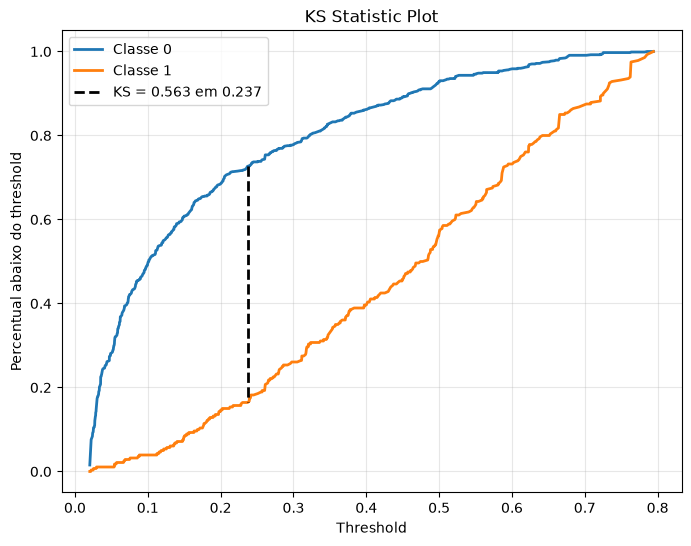

np.float64(0.5625184094256259)

In [10]:
plot_ks_curve(y_val, model.predict_proba(X_val)[:, 1])

In [11]:
metrics_val = evaluate_model(model, X_test, y_test, plot=False)
metrics_val.index = ['Test']
metrics_val

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Test,0.8,0.7,0.42,0.52,0.84


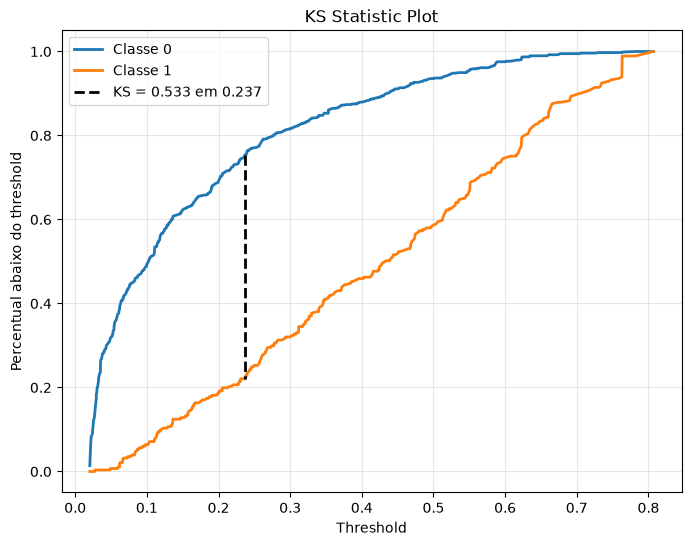

np.float64(0.5332254099864255)

In [12]:
plot_ks_curve(y_test, model.predict_proba(X_test)[:, 1])

# Primeiro Teste

In [74]:
"""
model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=42,
    n_jobs=-1,
    device="gpu",
    verbosity=-1
)

model.fit(X_train, y_train)

Primeiro teste com LGBM
"""

,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,device,'gpu'
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31


In [75]:
metrics_train = evaluate_model(model, X_train, y_train, plot=False)
metrics_train.index = ['Train']
metrics_val = evaluate_model(model, X_val, y_val, plot=False)
metrics_val.index = ['Validation']
metrics = pd.concat([metrics_train, metrics_val])
metrics

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Train,0.92,0.87,0.81,0.84,0.98
Validation,0.79,0.63,0.54,0.58,0.84


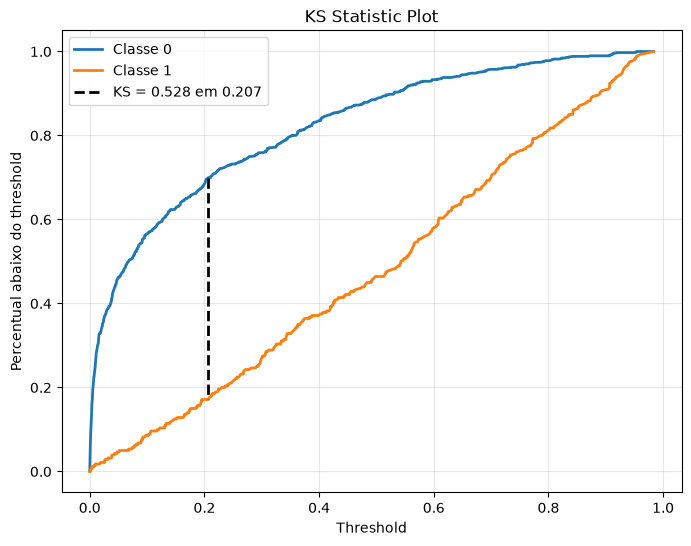

np.float64(0.5283136966126656)

In [76]:
plot_ks_curve(y_val, model.predict_proba(X_val)[:, 1])

In [79]:
metrics_val = evaluate_model(model, X_test, y_test, plot=False)
metrics_val.index = ['Test']
metrics_val

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Test,0.78,0.61,0.48,0.54,0.82


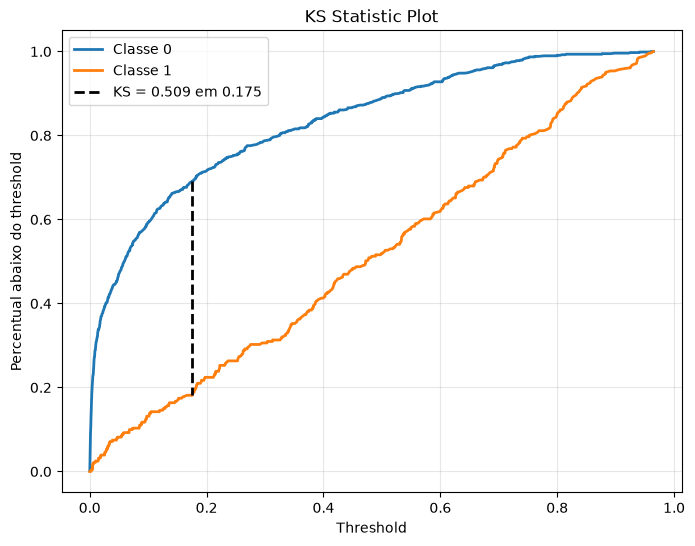

np.float64(0.5092269875628279)

In [78]:
plot_ks_curve(y_test, model.predict_proba(X_test)[:, 1])